# Bab 4 — Regresi dan Prediksi

Regresi merupakan salah satu teknik statistik yang paling penting untuk memahami hubungan antara variabel serta melakukan prediksi.

Dalam ilmu data, regresi digunakan untuk memprediksi suatu variabel hasil berdasarkan satu atau lebih variabel prediktor.

Ketika model dibangun menggunakan data yang nilai hasilnya sudah diketahui, kemudian digunakan untuk memprediksi data baru yang hasilnya belum diketahui, proses tersebut termasuk dalam **supervised learning**.

Bab ini membahas berbagai konsep regresi, mulai dari regresi linear sederhana hingga model regresi yang lebih kompleks.

## 4.1 Regresi Linear Sederhana

**Regresi linear sederhana** digunakan untuk memodelkan hubungan antara dua variabel.

Model ini memiliki:

- satu variabel prediktor atau variabel independen (X), dan
- satu variabel respons atau variabel dependen (Y).

Regresi tidak hanya mengukur seberapa kuat hubungan antara dua variabel, tetapi juga menggambarkan bentuk hubungan tersebut dalam sebuah persamaan.

Sebagai contoh:

- ketika X meningkat, Y dapat meningkat;
- ketika X meningkat, Y juga dapat menurun.

Berbeda dengan korelasi yang terutama mengukur kekuatan hubungan, regresi digunakan untuk mengukur dan memodelkan hubungan tersebut sehingga dapat digunakan untuk prediksi.

### Istilah Penting

**Response / Respons**  
Variabel yang ingin diprediksi.

Istilah lain:
- dependent variable
- target
- outcome
- variabel Y

**Predictor / Prediktor**  
Variabel yang digunakan untuk memprediksi respons.

Istilah lain:
- independent variable
- feature
- attribute
- variabel X

**Record**  
Sekumpulan nilai prediktor dan respons untuk satu observasi atau satu kasus.

**Intercept**  
Nilai prediksi Y ketika X = 0.

**Regression Coefficient / Koefisien Regresi**  
Menunjukkan perubahan nilai Y untuk setiap perubahan satu unit pada X.

### 4.1.1 Persamaan Regresi

Persamaan dasar regresi linear sederhana adalah:

\[
Y = b_0 + b_1X
\]

Keterangan:

- **Y** = variabel respons yang ingin diprediksi
- **X** = variabel prediktor
- **b₀** = intercept
- **b₁** = koefisien regresi atau slope

Intercept menunjukkan nilai prediksi Y ketika X = 0.

Koefisien regresi menunjukkan seberapa besar perubahan nilai Y ketika X meningkat satu unit.

Jika b₁ bernilai positif, Y cenderung meningkat ketika X meningkat.

Jika b₁ bernilai negatif, Y cenderung menurun ketika X meningkat.

In [1]:
# Mengimpor library yang dibutuhkan

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

In [2]:
# Memuat dataset LungDisease dari repositori resmi buku

url = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/LungDisease.csv"

lung = pd.read_csv(url)

lung.head()

,PEFR,Exposure
0,390,0
1,410,0
2,430,0
3,460,0
4,420,1


In [3]:
# Melihat informasi dataset

print("Ukuran dataset:", lung.shape)
print("\nNama kolom:")
print(lung.columns.tolist())

print("\nLima data pertama:")
display(lung.head())

Ukuran dataset: (122, 2)

Nama kolom:
['PEFR', 'Exposure']

Lima data pertama:


,PEFR,Exposure
0,390,0
1,410,0
2,430,0
3,460,0
4,420,1


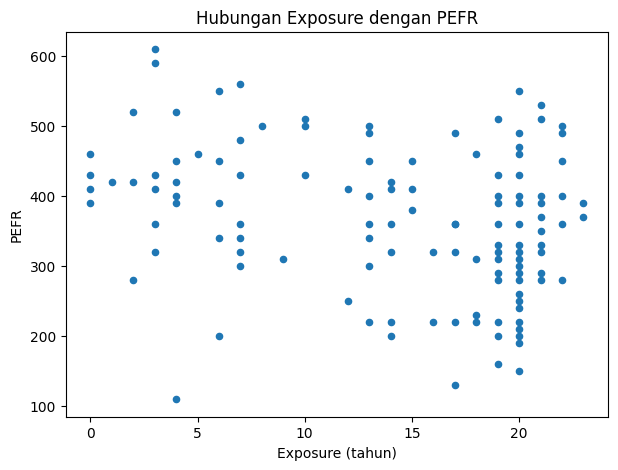

In [4]:
# Membuat scatter plot antara Exposure dan PEFR

lung.plot.scatter(
    x='Exposure',
    y='PEFR',
    figsize=(7, 5)
)

plt.xlabel('Exposure (tahun)')
plt.ylabel('PEFR')
plt.title('Hubungan Exposure dengan PEFR')
plt.show()

### Interpretasi Awal

Scatter plot menunjukkan hubungan antara lama paparan debu kapas (**Exposure**) dengan kapasitas paru yang diukur menggunakan **PEFR**.

Tujuan regresi linear sederhana adalah mencari garis yang paling sesuai untuk menggambarkan hubungan antara kedua variabel tersebut.

Model yang digunakan adalah:

\[
PEFR = b_0 + b_1(Exposure)
\]

Dalam model ini:

- **PEFR** merupakan variabel respons.
- **Exposure** merupakan variabel prediktor.

In [5]:
# Menentukan variabel prediktor dan respons

predictors = ['Exposure']
outcome = 'PEFR'

# Membuat model regresi linear
model = LinearRegression()

# Melatih model
model.fit(
    lung[predictors],
    lung[outcome]
)

# Menampilkan intercept dan koefisien
print(f"Intercept: {model.intercept_:.3f}")
print(f"Koefisien Exposure: {model.coef_[0]:.3f}")

Intercept: 424.583
Koefisien Exposure: -4.185


### Interpretasi Model Regresi

Hasil model menghasilkan:

\[
PEFR = 424.583 - 4.185(Exposure)
\]

#### Intercept = 424.583

Intercept menunjukkan nilai PEFR yang diprediksi ketika:

\[
Exposure = 0
\]

Dengan demikian, pekerja dengan paparan debu kapas selama 0 tahun diprediksi memiliki nilai PEFR sekitar **424.583**.

#### Koefisien Exposure = -4.185

Koefisien regresi bernilai negatif.

Artinya, setiap tambahan **1 tahun Exposure** dikaitkan dengan penurunan nilai PEFR yang diprediksi sekitar:

\[
4.185
\]

Dengan kata lain, semakin lama paparan terhadap debu kapas, model memprediksi nilai PEFR yang semakin rendah.

Koefisien negatif menunjukkan hubungan linear negatif antara Exposure dan PEFR.

### 4.1.2 Fitted Values dan Residuals

Dua konsep penting dalam analisis regresi adalah **fitted values** dan **residuals**.

Dalam kenyataannya, titik-titik data biasanya tidak berada tepat pada garis regresi. Oleh karena itu, persamaan regresi dapat ditulis dengan menambahkan komponen error:

\[
Y_i = b_0 + b_1X_i + e_i
\]

Keterangan:

- \(Y_i\) = nilai aktual
- \(b_0\) = intercept
- \(b_1\) = koefisien regresi
- \(X_i\) = nilai prediktor
- \(e_i\) = error atau residual

Nilai prediksi atau **fitted value** dinotasikan dengan:

\[
\hat{Y}_i = b_0 + b_1X_i
\]

Sedangkan residual dihitung dengan:

\[
e_i = Y_i - \hat{Y}_i
\]

Dengan demikian:

**Residual = Nilai Aktual - Nilai Prediksi**

Residual menunjukkan seberapa jauh hasil prediksi model dari nilai aktual untuk setiap observasi.

In [6]:
# Menghitung fitted values atau nilai prediksi

fitted = model.predict(lung[predictors])

print("10 fitted values pertama:")
print(fitted[:10])

10 fitted values pertama:
[424.58280657 424.58280657 424.58280657 424.58280657 420.39823009
 416.2136536  416.2136536  416.2136536  412.02907712 412.02907712]


In [7]:
# Menghitung residual

residuals = lung[outcome] - fitted

print("10 residual pertama:")
print(residuals.head(10))

10 residual pertama:
0    -34.582807
1    -14.582807
2      5.417193
3     35.417193
4     -0.398230
5   -136.213654
6      3.786346
7    103.786346
8    197.970923
9    177.970923
Name: PEFR, dtype: float64


In [8]:
# Membuat tabel hasil regresi

hasil_regresi = lung[['Exposure', 'PEFR']].copy()

hasil_regresi['Prediksi_PEFR'] = fitted
hasil_regresi['Residual'] = residuals

hasil_regresi.head(10)

,Exposure,PEFR,Prediksi_PEFR,Residual
0,0,390,424.582807,-34.582807
1,0,410,424.582807,-14.582807
2,0,430,424.582807,5.417193
3,0,460,424.582807,35.417193
4,1,420,420.398230,-0.398230
5,2,280,416.213654,-136.213654
6,2,420,416.213654,3.786346
7,2,520,416.213654,103.786346
8,3,610,412.029077,197.970923
9,3,590,412.029077,177.970923


### Interpretasi Fitted Values dan Residuals

Kolom **Prediksi_PEFR** menunjukkan nilai PEFR yang diperkirakan oleh model regresi untuk setiap nilai Exposure.

Kolom **Residual** menunjukkan perbedaan antara nilai PEFR aktual dengan nilai PEFR hasil prediksi.

Interpretasinya:

- Residual positif berarti nilai aktual lebih tinggi daripada prediksi model.
- Residual negatif berarti nilai aktual lebih rendah daripada prediksi model.
- Residual mendekati nol berarti hasil prediksi model dekat dengan nilai aktual.

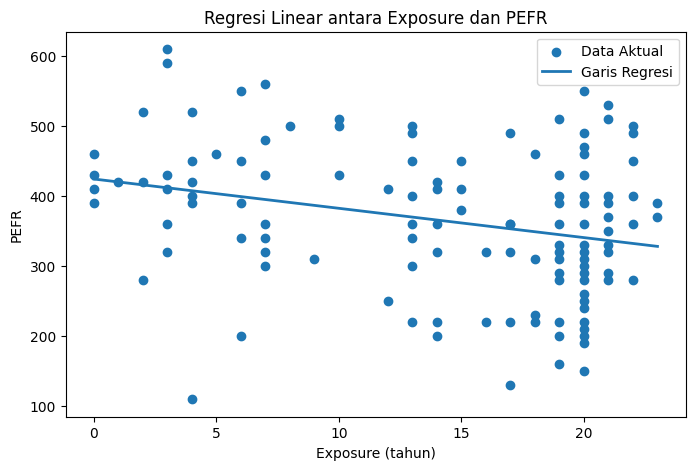

In [9]:
# Membuat scatter plot dan garis regresi

plt.figure(figsize=(8, 5))

plt.scatter(
    lung['Exposure'],
    lung['PEFR'],
    label='Data Aktual'
)

# Mengurutkan Exposure agar garis regresi tersambung dengan rapi
urutan = np.argsort(lung['Exposure'].values)

plt.plot(
    lung['Exposure'].values[urutan],
    fitted[urutan],
    linewidth=2,
    label='Garis Regresi'
)

plt.xlabel('Exposure (tahun)')
plt.ylabel('PEFR')
plt.title('Regresi Linear antara Exposure dan PEFR')
plt.legend()
plt.show()

### Interpretasi Garis Regresi

Garis regresi menunjukkan nilai PEFR yang diprediksi untuk setiap tingkat Exposure.

Karena koefisien Exposure bernilai negatif, garis regresi memiliki arah menurun.

Artinya, model menunjukkan bahwa semakin lama Exposure terhadap debu kapas, semakin rendah nilai PEFR yang diprediksi.

Namun, titik-titik observasi tidak seluruhnya berada tepat pada garis regresi.

Jarak antara titik observasi dengan garis regresi disebut **residual**.

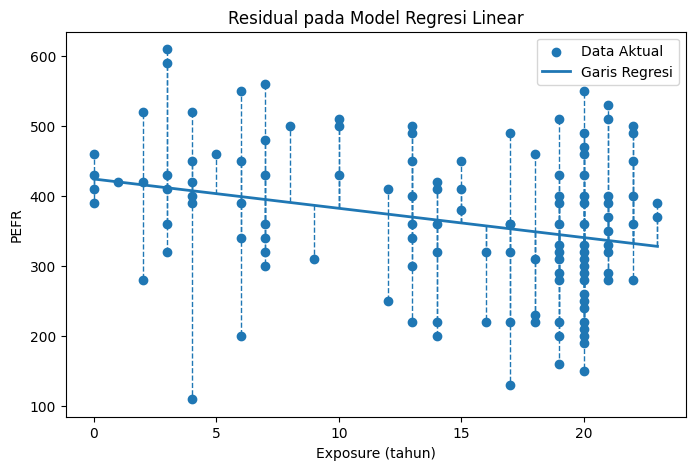

In [10]:
# Visualisasi residual sebagai jarak vertikal
# antara nilai aktual dan garis regresi

plt.figure(figsize=(8, 5))

plt.scatter(
    lung['Exposure'],
    lung['PEFR'],
    label='Data Aktual'
)

plt.plot(
    lung['Exposure'].values[urutan],
    fitted[urutan],
    linewidth=2,
    label='Garis Regresi'
)

# Menggambar residual
plt.vlines(
    x=lung['Exposure'],
    ymin=fitted,
    ymax=lung['PEFR'],
    linestyles='dashed',
    linewidth=1
)

plt.xlabel('Exposure (tahun)')
plt.ylabel('PEFR')
plt.title('Residual pada Model Regresi Linear')
plt.legend()
plt.show()

In [11]:
print(f"Rata-rata residual: {residuals.mean():.10f}")

Rata-rata residual: 0.0000000000


### Kesimpulan Fitted Values dan Residuals

- **Fitted value** adalah nilai hasil prediksi model regresi.
- **Residual** adalah selisih antara nilai aktual dan nilai prediksi.
- Residual dapat bernilai positif maupun negatif.
- Residual yang kecil menunjukkan bahwa prediksi model dekat dengan nilai aktual.
- Residual digunakan untuk mengevaluasi kesalahan prediksi dan kualitas model regresi.

### 4.1.3 Metode Kuadrat Terkecil

Model regresi linear umumnya diestimasi menggunakan metode **Least Squares** atau **Ordinary Least Squares (OLS)**. Metode ini bertujuan untuk menentukan garis regresi yang menghasilkan jumlah kuadrat residual paling kecil.

Residual pada setiap observasi merupakan selisih antara nilai aktual dan nilai prediksi, yang dirumuskan sebagai:

$$
e_i = Y_i - \hat{Y}_i
$$

Jumlah kuadrat residual atau **Residual Sum of Squares (RSS)** dihitung menggunakan persamaan:

$$
RSS = \sum_{i=1}^{n}(Y_i - \hat{Y}_i)^2
$$

Karena nilai prediksi pada regresi linear sederhana dinyatakan sebagai:

$$
\hat{Y}_i = b_0 + b_1X_i
$$

maka persamaan RSS dapat ditulis menjadi:

$$
RSS = \sum_{i=1}^{n}(Y_i - b_0 - b_1X_i)^2
$$

Nilai $b_0$ dan $b_1$ dipilih sedemikian rupa sehingga nilai **RSS menjadi sekecil mungkin**. Dengan demikian, garis regresi yang diperoleh merupakan garis yang memiliki total kesalahan kuadrat paling kecil terhadap seluruh observasi.

In [12]:
# Menghitung Residual Sum of Squares (RSS)

rss = np.sum(residuals ** 2)

print(f"Residual Sum of Squares (RSS): {rss:.2f}")

Residual Sum of Squares (RSS): 1234764.29


### Interpretasi RSS

RSS mengukur total kesalahan kuadrat dari seluruh prediksi model.

Semakin kecil nilai RSS, semakin dekat secara keseluruhan nilai prediksi model terhadap nilai aktual.

Residual dikuadratkan karena:

- residual positif dan negatif tidak saling menghilangkan,
- kesalahan yang besar mendapatkan penalti lebih besar.

Metode least squares memilih garis regresi yang menghasilkan RSS minimum.

In [13]:
# RSS dari model hasil LinearRegression

rss_model = np.sum(
    (lung['PEFR'] - fitted) ** 2
)

# Membuat garis alternatif dengan koefisien yang berbeda
prediksi_alternatif = 420 - 3 * lung['Exposure']

rss_alternatif = np.sum(
    (lung['PEFR'] - prediksi_alternatif) ** 2
)

print(f"RSS model regresi : {rss_model:.2f}")
print(f"RSS garis alternatif: {rss_alternatif:.2f}")

RSS model regresi : 1234764.29
RSS garis alternatif: 1260846.00


### Interpretasi

Model `LinearRegression` memilih kombinasi intercept dan koefisien yang meminimalkan jumlah kuadrat residual.

Jika kita menggunakan garis lain dengan intercept atau slope yang berbeda, nilai RSS umumnya akan menjadi lebih besar.

Inilah prinsip dasar dari Ordinary Least Squares.

### Sensitivitas terhadap Outlier

Metode least squares sensitif terhadap nilai ekstrem atau **outlier**.

Hal ini terjadi karena residual dikuadratkan.

Sebagai contoh:

- residual = 2 menghasilkan kuadrat residual = 4
- residual = 10 menghasilkan kuadrat residual = 100

Dengan demikian, observasi yang memiliki residual sangat besar dapat memberikan pengaruh yang besar terhadap posisi garis regresi.

Masalah outlier dalam regresi akan dibahas lebih lanjut pada bagian diagnostik regresi.

### 4.1.4 Prediksi vs Penjelasan

Regresi dapat digunakan untuk dua tujuan utama:

#### 1. Penjelasan

Tujuannya adalah memahami hubungan antara variabel prediktor dan variabel respons.

Dalam konteks ini, perhatian utama biasanya diberikan pada:

- arah hubungan,
- besar koefisien regresi,
- dan bagaimana perubahan X berkaitan dengan perubahan Y.

#### 2. Prediksi

Tujuannya adalah menggunakan model untuk memperkirakan nilai respons pada data baru yang belum diketahui.

Dalam konteks ini, perhatian lebih banyak diberikan pada:

- fitted values,
- akurasi prediksi,
- dan kemampuan model dalam melakukan prediksi pada data baru.

Dalam ilmu data modern, regresi sering digunakan sebagai model prediktif.

### Regresi Tidak Membuktikan Hubungan Sebab-Akibat

Walaupun model regresi dapat menunjukkan adanya hubungan antara X dan Y, regresi saja tidak dapat membuktikan bahwa X menyebabkan perubahan pada Y.

Sebagai contoh, sebuah model regresi dapat menunjukkan hubungan antara:

- jumlah klik pada iklan, dan
- jumlah konversi penjualan.

Namun, kesimpulan bahwa klik iklan menyebabkan penjualan membutuhkan pemahaman tambahan mengenai proses bisnis dan desain penelitian.

Dengan demikian:

**hubungan statistik tidak selalu berarti hubungan sebab-akibat.**

### Ringkasan Regresi Linear Sederhana

- Regresi linear sederhana memodelkan hubungan antara satu prediktor dan satu respons.
- Model menghasilkan fitted values dan residuals.
- Residual merupakan selisih antara nilai aktual dan nilai prediksi.
- Ordinary Least Squares memilih garis yang meminimalkan RSS.
- Least squares sensitif terhadap outlier.
- Regresi dapat digunakan untuk penjelasan maupun prediksi.
- Hubungan regresi tidak otomatis membuktikan hubungan sebab-akibat.

## 4.2 Regresi Linear Berganda

**Regresi linear berganda** digunakan ketika sebuah variabel respons diprediksi menggunakan lebih dari satu variabel prediktor.

Persamaan umum regresi linear berganda adalah:

$$
Y = b_0 + b_1X_1 + b_2X_2 + \cdots + b_pX_p + e
$$

Keterangan:

- $Y$ = variabel respons
- $X_1, X_2, \ldots, X_p$ = variabel prediktor
- $b_0$ = intercept atau konstanta
- $b_1, b_2, \ldots, b_p$ = koefisien regresi
- $e$ = error atau residual

Setiap koefisien regresi menunjukkan besarnya perubahan pada nilai prediksi $Y$ akibat perubahan satu unit pada prediktor yang bersangkutan, dengan asumsi bahwa prediktor lainnya tetap konstan.

Sebagai contoh, koefisien $b_1$ menunjukkan perubahan nilai prediksi $Y$ untuk setiap kenaikan satu unit pada $X_1$, dengan nilai $X_2, X_3, \ldots, X_p$ dianggap tetap.

### Istilah Penting dalam Regresi Linear Berganda

**RMSE (Root Mean Squared Error)**  
Akar dari rata-rata kuadrat kesalahan prediksi. RMSE sering digunakan untuk membandingkan performa model regresi.

**RSE (Residual Standard Error)**  
Ukuran kesalahan residual yang mirip dengan RMSE, tetapi disesuaikan dengan degrees of freedom.

**R-squared (R²)**  
Menunjukkan proporsi variasi pada variabel respons yang dapat dijelaskan oleh model.

Nilai R² berada antara 0 dan 1.

**t-statistic**  
Koefisien prediktor dibagi dengan standard error koefisien tersebut.

**Weighted Regression**  
Regresi yang memberikan bobot berbeda pada setiap observasi.

### 4.2.1 Contoh: King County Housing Data

Pada contoh ini, tujuan model adalah memprediksi harga jual rumah berdasarkan beberapa karakteristik properti.

Variabel respons:

- **AdjSalePrice** = harga jual rumah yang telah disesuaikan

Variabel prediktor:

- **SqFtTotLiving** = luas total area tempat tinggal
- **SqFtLot** = luas tanah
- **Bathrooms** = jumlah kamar mandi
- **Bedrooms** = jumlah kamar tidur
- **BldgGrade** = kualitas atau grade bangunan

Model regresi akan memperkirakan AdjSalePrice berdasarkan kelima variabel tersebut.

In [14]:
# Memuat King County Housing Data dari repositori resmi buku

url_house = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/house_sales.csv"

house = pd.read_csv(
    url_house,
    sep='\t'
)

print("Ukuran dataset:", house.shape)

house.head()

Ukuran dataset: (22687, 22)


,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,...,Bathrooms,Bedrooms,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction
1,2014-09-16,280000,1000102,Multiplex,2014-09-01,405100,0.930836,300805.0,2,9373,...,3.00,6,7,1991,0,0,70000,229000,98002,False
2,2006-06-16,1000000,1200013,Single Family,2006-06-01,404400,0.929228,1076162.0,1,20156,...,3.75,4,10,2005,0,0,203000,590000,98166,True
3,2007-01-29,745000,1200019,Single Family,2007-01-01,425600,0.977941,761805.0,1,26036,...,1.75,4,8,1947,0,0,183000,275000,98166,False
4,2008-02-25,425000,2800016,Single Family,2008-02-01,418400,0.961397,442065.0,1,8618,...,3.75,5,7,1966,0,0,104000,229000,98168,False
5,2013-03-29,240000,2800024,Single Family,2013-03-01,351600,0.807904,297065.0,1,8620,...,1.75,4,7,1948,0,0,104000,205000,98168,False


In [15]:
# Menampilkan variabel yang digunakan dalam model

subset = [
    'AdjSalePrice',
    'SqFtTotLiving',
    'SqFtLot',
    'Bathrooms',
    'Bedrooms',
    'BldgGrade'
]

house[subset].head()

,AdjSalePrice,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade
1,300805.0,2400,9373,3.00,6,7
2,1076162.0,3764,20156,3.75,4,10
3,761805.0,2060,26036,1.75,4,8
4,442065.0,3200,8618,3.75,5,7
5,297065.0,1720,8620,1.75,4,7


In [16]:
# Mengecek missing values

house[subset].isna().sum()

,0
AdjSalePrice,0
SqFtTotLiving,0
SqFtLot,0
Bathrooms,0
Bedrooms,0
BldgGrade,0


In [17]:
house_model = house[subset].dropna().copy()

print("Jumlah data setelah menghapus missing values:")
print(house_model.shape)

Jumlah data setelah menghapus missing values:
(22687, 6)


In [18]:
# Menentukan prediktor dan respons

predictors = [
    'SqFtTotLiving',
    'SqFtLot',
    'Bathrooms',
    'Bedrooms',
    'BldgGrade'
]

outcome = 'AdjSalePrice'

# Membuat model regresi linear berganda
house_lm = LinearRegression()

# Melatih model
house_lm.fit(
    house_model[predictors],
    house_model[outcome]
)

LinearRegression()

In [19]:
print(f"Intercept: {house_lm.intercept_:.3f}")

print("\nKoefisien:")

for name, coef in zip(
    predictors,
    house_lm.coef_
):
    print(f"{name}: {coef:.3f}")

Intercept: -521871.368

Koefisien:
SqFtTotLiving: 228.831
SqFtLot: -0.060
Bathrooms: -19442.840
Bedrooms: -47769.955
BldgGrade: 106106.963


In [20]:
koefisien_model = pd.DataFrame({
    'Variabel': predictors,
    'Koefisien': house_lm.coef_
})

koefisien_model

,Variabel,Koefisien
0,SqFtTotLiving,228.830604
1,SqFtLot,-0.060467
2,Bathrooms,-19442.840398
3,Bedrooms,-47769.955185
4,BldgGrade,106106.963079


### Interpretasi Koefisien

Dalam regresi linear berganda, setiap koefisien diinterpretasikan dengan asumsi bahwa prediktor lainnya tetap.

Sebagai contoh:

#### SqFtTotLiving

Koefisiennya sekitar:

\[
228.8
\]

Artinya, dengan karakteristik rumah lainnya dianggap tetap, tambahan **1 square foot** luas tempat tinggal dikaitkan dengan kenaikan harga rumah yang diprediksi sekitar **$229**.

Tambahan 1.000 square feet berarti kenaikan harga prediksi sekitar:

\[
228.8 \times 1000 = 228,800
\]

atau sekitar **$228.800**.

Namun, koefisien regresi harus dibaca dalam konteks seluruh model karena setiap prediktor dianalisis dengan mempertahankan prediktor lainnya tetap.

### Catatan tentang Koefisien Negatif

Beberapa koefisien dalam model dapat terlihat tidak intuitif.

Sebagai contoh, koefisien **Bedrooms** atau **Bathrooms** dapat bernilai negatif meskipun rumah dengan lebih banyak kamar sering dianggap lebih mahal.

Hal ini tidak berarti bahwa menambah kamar secara langsung akan menurunkan harga rumah.

Dalam regresi berganda, setiap koefisien menggambarkan pengaruh suatu prediktor ketika prediktor lainnya dianggap tetap.

Karena beberapa karakteristik rumah dapat saling berkaitan, interpretasi koefisien regresi berganda harus mempertimbangkan hubungan antarvariabel dalam model.

### 4.2.2 Evaluasi Model Regresi

Setelah model regresi dibangun, langkah berikutnya adalah mengevaluasi seberapa baik model tersebut dalam menjelaskan dan memprediksi data.

Beberapa ukuran yang umum digunakan untuk mengevaluasi model regresi adalah **RMSE**, **RSE**, dan **R-squared**.

#### RMSE (Root Mean Squared Error)

**Root Mean Squared Error (RMSE)** mengukur rata-rata besar kesalahan prediksi model dalam satuan yang sama dengan variabel respons.

Rumus RMSE adalah:

$$
RMSE = \sqrt{\frac{\sum_{i=1}^{n}(Y_i-\hat{Y}_i)^2}{n}}
$$

Keterangan:

- $Y_i$ = nilai aktual pada observasi ke-$i$
- $\hat{Y}_i$ = nilai prediksi pada observasi ke-$i$
- $n$ = jumlah observasi

Semakin kecil nilai **RMSE**, semakin kecil kesalahan prediksi yang dihasilkan oleh model.

---

#### RSE (Residual Standard Error)

**Residual Standard Error (RSE)** mengukur besarnya variasi residual atau kesalahan prediksi model. RSE memiliki konsep yang hampir sama dengan RMSE, tetapi penyebutnya disesuaikan dengan **degrees of freedom**.

Rumus RSE adalah:

$$
RSE = \sqrt{\frac{\sum_{i=1}^{n}(Y_i-\hat{Y}_i)^2}{n-p-1}}
$$

Keterangan:

- $Y_i$ = nilai aktual pada observasi ke-$i$
- $\hat{Y}_i$ = nilai prediksi pada observasi ke-$i$
- $n$ = jumlah observasi
- $p$ = jumlah variabel prediktor

Semakin kecil nilai **RSE**, semakin kecil variasi residual yang dihasilkan oleh model.

---

#### R-squared ($R^2$)

**R-squared ($R^2$)** atau koefisien determinasi menunjukkan proporsi variasi pada variabel respons yang dapat dijelaskan oleh model regresi.

Secara umum, nilai $R^2$ berada antara 0 dan 1.

- Nilai $R^2$ yang mendekati **1** menunjukkan bahwa model dapat menjelaskan sebagian besar variasi pada variabel respons.
- Nilai $R^2$ yang mendekati **0** menunjukkan bahwa hanya sebagian kecil variasi pada variabel respons yang dapat dijelaskan oleh model.

Namun, nilai $R^2$ yang tinggi tidak selalu berarti bahwa model memiliki kemampuan prediksi yang baik. Oleh karena itu, evaluasi model sebaiknya juga mempertimbangkan ukuran kesalahan prediksi seperti **RMSE** dan **RSE**.

In [22]:
from sklearn.metrics import mean_squared_error, r2_score

In [23]:
# Menghasilkan fitted values

fitted = house_lm.predict(
    house_model[predictors]
)

# Menghitung RMSE
RMSE = np.sqrt(
    mean_squared_error(
        house_model[outcome],
        fitted
    )
)

# Menghitung R-squared
r2 = r2_score(
    house_model[outcome],
    fitted
)

print(f"RMSE: {RMSE:.0f}")
print(f"R-squared: {r2:.4f}")

RMSE: 261220
R-squared: 0.5406


### Interpretasi RMSE dan R²

Nilai RMSE menunjukkan besar rata-rata kesalahan prediksi model dalam satuan harga rumah.

Karena variabel respons adalah **AdjSalePrice**, maka RMSE juga dinyatakan dalam satuan harga.

Nilai R² sekitar:

\[
R^2 \approx 0.5406
\]

Artinya, sekitar **54,06% variasi AdjSalePrice** dalam data dapat dijelaskan oleh kombinasi prediktor:

- SqFtTotLiving
- SqFtLot
- Bathrooms
- Bedrooms
- BldgGrade

Sisanya tidak dijelaskan oleh model ini dan dapat berkaitan dengan variabel lain atau variasi residual.

In [24]:
# Menghitung residual

residuals_house = (
    house_model[outcome] - fitted
)

# Residual Sum of Squares
rss_house = np.sum(
    residuals_house ** 2
)

n = len(house_model)
p = len(predictors)

# Residual Standard Error
RSE = np.sqrt(
    rss_house / (n - p - 1)
)

print(f"Jumlah observasi: {n}")
print(f"Jumlah prediktor: {p}")
print(f"RSE: {RSE:.0f}")

Jumlah observasi: 22687
Jumlah prediktor: 5
RSE: 261255


### Interpretasi RSE

RSE mengukur besarnya variasi residual setelah menyesuaikan jumlah prediktor yang digunakan dalam model.

Pada model ini, nilai RSE sekitar 261 ribu.

Nilai tersebut relatif dekat dengan RMSE karena jumlah observasi jauh lebih besar dibandingkan jumlah prediktor.

In [25]:
import statsmodels.api as sm

In [26]:
# Membuat model OLS dengan statsmodels

X = house_model[predictors].assign(const=1)

model_sm = sm.OLS(
    house_model[outcome],
    X
)

results = model_sm.fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           AdjSalePrice   R-squared:                       0.541
Model:                            OLS   Adj. R-squared:                  0.540
Method:                 Least Squares   F-statistic:                     5338.
Date:                Sat, 03 Oct 2026   Prob (F-statistic):               0.00
Time:                        10:06:51   Log-Likelihood:            -3.1517e+05
No. Observations:               22687   AIC:                         6.304e+05
Df Residuals:                   22681   BIC:                         6.304e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
SqFtTotLiving   228.8306      3.899     58.694      0.000     221.189     236.472
SqFtLot          -0.0605      0.061     -0.988      0.323      -0.180       0.059
Bathrooms     -1.944e+04   3625.388     -5.363      0.000   -2.65e+04   -1.23e+04
Bedrooms      -4.777e+04   2489.732    -19.187      0.000   -5.27e+04   -4.29e+04
BldgGrade      1.061e+05   2396.445     44.277      0.000    1.01e+05    1.11e+05
const         -5.219e+05   1.57e+04    -33.342      0.000   -5.53e+05   -4.91e+05
==============================================================================
Omnibus:                    29676.557   Durbin-Watson:                   1.247
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         19390738.346
Skew:                           6.889   Prob(JB):                         0.00
Kurtosis:                     145.559   Cond. No.                     2.86e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.86e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Membaca Ringkasan Model OLS

Output `statsmodels` memberikan informasi yang lebih lengkap mengenai model regresi.

Beberapa bagian penting adalah:

#### coef

Menunjukkan estimasi koefisien regresi untuk masing-masing prediktor.

#### std err

Menunjukkan standard error dari estimasi koefisien.

#### t

Menunjukkan nilai t-statistic.

Secara umum:

$$
t =
\frac{
\text{Koefisien}
}{
\text{Standard Error}
}
$$

#### P>|t|

Menunjukkan p-value dari pengujian koefisien regresi.

#### R-squared

Menunjukkan proporsi variasi variabel respons yang dijelaskan oleh model.

#### Adj. R-squared

Merupakan R² yang telah disesuaikan dengan jumlah prediktor dalam model.

Adjusted R² memberikan penalti ketika prediktor tambahan dimasukkan tetapi tidak memberikan peningkatan penjelasan yang cukup terhadap model.

In [27]:
print(f"R-squared          : {results.rsquared:.4f}")
print(f"Adjusted R-squared : {results.rsquared_adj:.4f}")
print(f"RMSE               : {RMSE:.2f}")
print(f"RSE                : {RSE:.2f}")

R-squared          : 0.5406
Adjusted R-squared : 0.5405
RMSE               : 261220.20
RSE                : 261254.75


### Ringkasan Evaluasi Model

- **RMSE** mengukur besar kesalahan prediksi rata-rata dalam satuan variabel respons.
- **RSE** mirip dengan RMSE, tetapi menyesuaikan degrees of freedom.
- **R²** menunjukkan proporsi variasi respons yang dapat dijelaskan oleh model.
- **Adjusted R²** menyesuaikan R² berdasarkan jumlah prediktor.
- Model King County Housing menghasilkan R² sekitar 0.5406.
- Artinya, sekitar 54% variasi harga rumah pada data tersebut dapat dijelaskan oleh lima prediktor dalam model.
- `statsmodels` memberikan informasi tambahan seperti standard error, t-statistic, dan p-value untuk setiap koefisien.

### 4.2.3 Cross-Validation

Metrik seperti **R², F-statistic, dan p-value** merupakan metrik **in-sample**, karena dihitung menggunakan data yang sama dengan data yang digunakan untuk membangun model.

Masalahnya, model yang terlihat baik pada data pelatihan belum tentu memiliki performa yang sama ketika digunakan pada data baru.

Salah satu pendekatan untuk mengevaluasi kemampuan model dalam melakukan generalisasi adalah **cross-validation**.

Cross-validation mengevaluasi model menggunakan bagian data yang tidak digunakan ketika model tersebut dilatih.

#### K-Fold Cross-Validation

Pada **k-fold cross-validation**, dataset dibagi menjadi \(k\) bagian yang disebut **fold**.

Prosedur dasarnya adalah:

1. Pisahkan \(1/k\) bagian data sebagai data holdout.
2. Gunakan sisa data untuk melatih model.
3. Gunakan model untuk memprediksi data holdout.
4. Hitung metrik evaluasi pada data holdout.
5. Kembalikan data holdout pertama, kemudian pilih fold berikutnya sebagai holdout.
6. Ulangi proses hingga setiap observasi pernah menjadi bagian dari data holdout.
7. Gabungkan atau rata-ratakan hasil evaluasi dari seluruh fold.

Dengan cara ini, seluruh data dapat digunakan baik sebagai data pelatihan maupun data validasi pada tahap yang berbeda.

In [29]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [31]:
# Menyiapkan variabel prediktor dan respons

X_cv = house_model[predictors]
y_cv = house_model[outcome]

# Membuat 5 fold
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

rmse_scores = []
r2_scores = []

In [32]:
# Menjalankan 5-fold cross-validation

for fold, (train_index, test_index) in enumerate(kf.split(X_cv), start=1):

    X_train = X_cv.iloc[train_index]
    X_test = X_cv.iloc[test_index]

    y_train = y_cv.iloc[train_index]
    y_test = y_cv.iloc[test_index]

    # Membuat model baru untuk setiap fold
    model_cv = LinearRegression()

    # Melatih model
    model_cv.fit(X_train, y_train)

    # Prediksi terhadap data holdout
    y_pred = model_cv.predict(X_test)

    # Menghitung RMSE
    rmse = np.sqrt(
        mean_squared_error(y_test, y_pred)
    )

    # Menghitung R-squared
    r2 = r2_score(
        y_test,
        y_pred
    )

    rmse_scores.append(rmse)
    r2_scores.append(r2)

    print(
        f"Fold {fold}: "
        f"RMSE = {rmse:.2f}, "
        f"R² = {r2:.4f}"
    )

Fold 1: RMSE = 246891.84, R² = 0.5665
Fold 2: RMSE = 288346.80, R² = 0.5142
Fold 3: RMSE = 256308.30, R² = 0.5360
Fold 4: RMSE = 270674.09, R² = 0.5360
Fold 5: RMSE = 242404.43, R² = 0.5524


In [33]:
# Menghitung rata-rata performa seluruh fold

mean_rmse = np.mean(rmse_scores)
mean_r2 = np.mean(r2_scores)

print("\nHasil rata-rata 5-Fold Cross-Validation")
print(f"Rata-rata RMSE : {mean_rmse:.2f}")
print(f"Rata-rata R²   : {mean_r2:.4f}")


Hasil rata-rata 5-Fold Cross-Validation
Rata-rata RMSE : 260925.09
Rata-rata R²   : 0.5410


In [34]:
print(f"Standar deviasi RMSE : {np.std(rmse_scores):.2f}")
print(f"Standar deviasi R²   : {np.std(r2_scores):.4f}")

Standar deviasi RMSE : 16782.46
Standar deviasi R²   : 0.0176


In [35]:
hasil_cv = pd.DataFrame({
    'Fold': range(1, 6),
    'RMSE': rmse_scores,
    'R-squared': r2_scores
})

hasil_cv

,Fold,RMSE,R-squared
0,1,246891.841022,0.566539
1,2,288346.798497,0.514224
2,3,256308.303810,0.536035
3,4,270674.090187,0.535955
4,5,242404.428038,0.552403


In [36]:
print("\nRata-rata seluruh fold:")
print(hasil_cv[['RMSE', 'R-squared']].mean())


Rata-rata seluruh fold:
RMSE         260925.092311
R-squared         0.541031
dtype: float64


### Interpretasi Cross-Validation

Pada setiap fold, model dilatih menggunakan sebagian besar data dan diuji menggunakan data yang tidak digunakan dalam proses pelatihan.

Dengan demikian, hasil cross-validation memberikan gambaran yang lebih realistis mengenai kemampuan model dalam melakukan prediksi terhadap data baru.

Performa model dapat berbeda antar-fold karena setiap fold memiliki kumpulan data holdout yang berbeda.

Rata-rata RMSE dan R² dari seluruh fold dapat digunakan untuk mengevaluasi kestabilan dan kemampuan generalisasi model.

Jika performa pada data cross-validation jauh lebih buruk dibandingkan performa pada seluruh data training, hal tersebut dapat menjadi indikasi bahwa model terlalu menyesuaikan diri dengan data training.

In [37]:
print("Evaluasi In-Sample")
print(f"RMSE : {RMSE:.2f}")
print(f"R²   : {r2:.4f}")

print("\nEvaluasi 5-Fold Cross-Validation")
print(f"RMSE rata-rata : {mean_rmse:.2f}")
print(f"R² rata-rata   : {mean_r2:.4f}")

Evaluasi In-Sample
RMSE : 261220.20
R²   : 0.5524

Evaluasi 5-Fold Cross-Validation
RMSE rata-rata : 260925.09
R² rata-rata   : 0.5410


In [38]:
# Menghitung ulang metrik in-sample model awal

fitted_full = house_lm.predict(
    house_model[predictors]
)

rmse_in_sample = np.sqrt(
    mean_squared_error(
        house_model[outcome],
        fitted_full
    )
)

r2_in_sample = r2_score(
    house_model[outcome],
    fitted_full
)

print("Evaluasi In-Sample")
print(f"RMSE : {rmse_in_sample:.2f}")
print(f"R²   : {r2_in_sample:.4f}")

print("\nEvaluasi 5-Fold Cross-Validation")
print(f"RMSE rata-rata : {mean_rmse:.2f}")
print(f"R² rata-rata   : {mean_r2:.4f}")

Evaluasi In-Sample
RMSE : 261220.20
R²   : 0.5406

Evaluasi 5-Fold Cross-Validation
RMSE rata-rata : 260925.09
R² rata-rata   : 0.5410


### Kesimpulan Cross-Validation

- Metrik in-sample mengevaluasi model menggunakan data yang juga digunakan untuk melatih model.
- Cross-validation mengevaluasi model pada data yang sementara tidak digunakan dalam proses pelatihan.
- K-fold cross-validation membagi dataset menjadi beberapa fold.
- Setiap fold bergantian digunakan sebagai data holdout.
- Hasil dari seluruh fold kemudian dirata-ratakan.
- Cross-validation membantu menilai kemampuan model untuk melakukan generalisasi terhadap data baru.
- Pendekatan ini juga membantu mengurangi ketergantungan terhadap satu pembagian training dan holdout tertentu.

### 4.2.4 Pemilihan Model dan Stepwise Regression

Dalam regresi berganda, sering kali tersedia banyak variabel yang dapat digunakan sebagai prediktor.

Namun, memasukkan lebih banyak variabel tidak selalu menghasilkan model yang lebih baik.

Secara umum, model yang lebih sederhana lebih disukai jika memiliki performa yang hampir sama dengan model yang lebih kompleks.

Prinsip ini sering dikaitkan dengan **Occam's Razor**:

> Jika dua model memiliki kemampuan yang hampir sama, pilih model yang lebih sederhana.

Pemilihan model bertujuan untuk mencari kombinasi prediktor yang memberikan keseimbangan antara:

- kemampuan model menjelaskan data,
- kemampuan prediksi,
- dan kompleksitas model.

In [39]:
# Prediktor untuk full model

predictors_full = [
    'SqFtTotLiving',
    'SqFtLot',
    'Bathrooms',
    'Bedrooms',
    'BldgGrade',
    'PropertyType',
    'NbrLivingUnits',
    'SqFtFinBasement',
    'YrBuilt',
    'YrRenovated',
    'NewConstruction'
]

In [40]:
# Mengubah variabel kategorikal menjadi numerik

X_full = pd.get_dummies(
    house[predictors_full],
    drop_first=True
)

# Memastikan semua kolom numerik
X_full = X_full.astype(float)

y_full = house[outcome]

print("Jumlah prediktor setelah dummy encoding:")
print(X_full.shape[1])

X_full.head()

Jumlah prediktor setelah dummy encoding:
12


,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade,NbrLivingUnits,SqFtFinBasement,YrBuilt,YrRenovated,NewConstruction,PropertyType_Single Family,PropertyType_Townhouse
1,2400.0,9373.0,3.00,6.0,7.0,2.0,0.0,1991.0,0.0,0.0,0.0,0.0
2,3764.0,20156.0,3.75,4.0,10.0,1.0,1452.0,2005.0,0.0,1.0,1.0,0.0
3,2060.0,26036.0,1.75,4.0,8.0,1.0,900.0,1947.0,0.0,0.0,1.0,0.0
4,3200.0,8618.0,3.75,5.0,7.0,1.0,1640.0,1966.0,0.0,0.0,1.0,0.0
5,1720.0,8620.0,1.75,4.0,7.0,1.0,0.0,1948.0,0.0,0.0,1.0,0.0


In [41]:
# Menambahkan intercept

X_full_sm = sm.add_constant(X_full)

# Membuat full model

house_full = sm.OLS(
    y_full,
    X_full_sm
).fit()

house_full.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           AdjSalePrice   R-squared:                       0.595
Model:                            OLS   Adj. R-squared:                  0.594
Method:                 Least Squares   F-statistic:                     2771.
Date:                Sat, 03 Oct 2026   Prob (F-statistic):               0.00
Time:                        10:19:08   Log-Likelihood:            -3.1375e+05
No. Observations:               22687   AIC:                         6.275e+05
Df Residuals:                   22674   BIC:                         6.276e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                       6.182e+06   1.55e+05     39.902      0.000    5.88e+06    6.49e+06
SqFtTotLiving                198.6364      4.234     46.920      0.000     190.338     206.934
SqFtLot                        0.0771      0.058      1.330      0.184      -0.037       0.191
Bathrooms                   4.286e+04   3808.114     11.255      0.000    3.54e+04    5.03e+04
Bedrooms                   -5.187e+04   2396.904    -21.638      0.000   -5.66e+04   -4.72e+04
BldgGrade                   1.373e+05   2441.242     56.228      0.000    1.32e+05    1.42e+05
NbrLivingUnits              5723.8438   1.76e+04      0.326      0.744   -2.87e+04    4.01e+04
SqFtFinBasement                7.0611      4.627      1.526      0.127      -2.009      16.131
YrBuilt                    -3574.2210     77.228    -46.282      0.000   -3725.593   -3422.849
YrRenovated                   -2.5311      3.924     -0.645      0.519     -10.222       5.160
NewConstruction            -2489.1122   5936.692     -0.419      0.675   -1.41e+04    9147.211
PropertyType_Single Family  2.997e+04   2.61e+04      1.149      0.251   -2.12e+04    8.11e+04
PropertyType_Townhouse      9.286e+04    2.7e+04      3.438      0.001    3.99e+04    1.46e+05
==============================================================================
Omnibus:                    31006.128   Durbin-Watson:                   1.393
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         26251977.078
Skew:                           7.427   Prob(JB):                         0.00
Kurtosis:                     168.984   Cond. No.                     2.98e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.98e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Interpretasi Full Model

Full model menggunakan lebih banyak prediktor dibandingkan model sebelumnya.

Namun, model yang memiliki lebih banyak prediktor tidak otomatis lebih baik.

Penambahan prediktor dapat:

- meningkatkan R² pada data training,
- menurunkan error pada data training,
- tetapi juga meningkatkan kompleksitas model,
- dan berpotensi menyebabkan overfitting.

Oleh karena itu, diperlukan ukuran yang mempertimbangkan kualitas model sekaligus kompleksitasnya.

### Adjusted R-squared

R² biasanya meningkat atau setidaknya tidak menurun ketika prediktor baru ditambahkan.

Karena itu, R² biasa dapat mendorong penggunaan model yang terlalu kompleks.

**Adjusted R²** memperhitungkan jumlah prediktor dalam model.

Rumusnya:

$$
R^2_{adj}
=
1 -
(1-R^2)
\frac{n-1}{n-P-1}
$$

Keterangan:

- \(n\) = jumlah observasi
- \(P\) = jumlah prediktor
- \(R^2\) = koefisien determinasi

Adjusted R² memberikan penalti terhadap penambahan variabel yang tidak memberikan peningkatan model yang cukup berarti.

In [42]:
print(f"R-squared          : {house_full.rsquared:.4f}")
print(f"Adjusted R-squared : {house_full.rsquared_adj:.4f}")

R-squared          : 0.5946
Adjusted R-squared : 0.5944


### Akaike Information Criterion (AIC)

AIC merupakan ukuran yang digunakan untuk membandingkan beberapa model.

AIC mempertimbangkan dua aspek:

1. kualitas kecocokan model terhadap data,
2. kompleksitas model.

Secara sederhana:

$$
AIC = 2P + n\log(RSS/n)
$$

Penambahan prediktor meningkatkan kompleksitas model dan menyebabkan penalti pada nilai AIC.

Dalam pemilihan model:

**model dengan nilai AIC yang lebih kecil lebih disukai.**

In [43]:
print(f"AIC Full Model: {house_full.aic:.2f}")

AIC Full Model: 627528.36


### Ukuran Pemilihan Model Lainnya

Selain AIC, terdapat beberapa ukuran lain:

**AICc**  
Versi AIC yang dikoreksi untuk ukuran sampel kecil.

**BIC (Bayesian Information Criterion)**  
Mirip dengan AIC, tetapi memberikan penalti yang lebih kuat terhadap model yang memiliki terlalu banyak parameter.

**Mallows Cp**  
Ukuran lain yang digunakan untuk menilai keseimbangan antara kualitas model dan kompleksitas.

Dalam praktik data science, cross-validation sering digunakan untuk mengevaluasi model secara langsung pada data holdout.

### Stepwise Regression

**Stepwise regression** merupakan metode pemilihan variabel secara bertahap.

Terdapat beberapa pendekatan:

#### Forward Selection

Dimulai tanpa prediktor.

Prediktor kemudian ditambahkan satu per satu berdasarkan kontribusinya terhadap model.

#### Backward Elimination

Dimulai dengan seluruh prediktor.

Prediktor yang memberikan kontribusi paling kecil kemudian dihapus secara bertahap.

#### Stepwise Selection

Merupakan kombinasi keduanya.

Pada setiap tahap, prediktor dapat:

- ditambahkan,
- atau dihapus,

untuk mencari model yang memberikan nilai kriteria terbaik, misalnya AIC.

In [44]:
!pip install dmba -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 71.7 MB/s eta 0:00:00


In [45]:
from dmba import stepwise_selection, AIC_score

Colab environment detected.


In [47]:
X = pd.get_dummies(
    house[predictors_full],
    drop_first=True
)

X = X.astype(float)

y = house[outcome]

In [48]:
def train_model(variables):

    if len(variables) == 0:
        return None

    model = LinearRegression()

    model.fit(
        X[list(variables)],
        y
    )

    return model


def score_model(model, variables):

    if len(variables) == 0:
        return AIC_score(
            y,
            [y.mean()] * len(y),
            model,
            df=1
        )

    return AIC_score(
        y,
        model.predict(X[list(variables)]),
        model
    )

In [49]:
best_model, best_variables = stepwise_selection(
    X.columns,
    train_model,
    score_model,
    verbose=True
)

Variables: SqFtTotLiving, SqFtLot, Bathrooms, Bedrooms, BldgGrade, NbrLivingUnits, SqFtFinBasement, YrBuilt, YrRenovated, NewConstruction, PropertyType_Single Family, PropertyType_Townhouse
Start: score=647988.32, constant
Step: score=633013.35, add SqFtTotLiving
Step: score=630793.74, add BldgGrade
Step: score=628230.29, add YrBuilt
Step: score=627784.16, add Bedrooms
Step: score=627602.21, add Bathrooms
Step: score=627525.65, add PropertyType_Townhouse
Step: score=627525.08, add SqFtFinBasement
Step: score=627524.98, add PropertyType_Single Family
Step: score=627524.98, unchanged None


In [50]:
print("\nVariabel terpilih:")

for variable in best_variables:
    print("-", variable)

print(f"\nIntercept: {best_model.intercept_:.3f}")

print("\nKoefisien:")

for name, coef in zip(
    best_variables,
    best_model.coef_
):
    print(f"{name}: {coef:.3f}")


Variabel terpilih:
- SqFtTotLiving
- BldgGrade
- YrBuilt
- Bedrooms
- Bathrooms
- PropertyType_Townhouse
- SqFtFinBasement
- PropertyType_Single Family

Intercept: 6178645.017

Koefisien:
SqFtTotLiving: 199.278
BldgGrade: 137159.560
YrBuilt: -3565.425
Bedrooms: -51947.384
Bathrooms: 42396.165
PropertyType_Townhouse: 84479.162
SqFtFinBasement: 7.047
PropertyType_Single Family: 22912.055


### Interpretasi Stepwise Regression

Stepwise regression menghasilkan model yang lebih sederhana dibandingkan full model.

Beberapa variabel yang tidak memberikan kontribusi yang cukup besar terhadap kualitas model dihapus.

Pada contoh King County Housing Data, beberapa prediktor yang dikeluarkan adalah:

- SqFtLot
- NbrLivingUnits
- YrRenovated
- NewConstruction

Model yang lebih sederhana dapat lebih mudah:

- diinterpretasikan,
- dipelihara,
- dan digunakan untuk prediksi.

Namun, stepwise regression tetap merupakan metode **in-sample**.

Artinya, proses pemilihan variabel dilakukan berdasarkan data yang sama dengan data yang digunakan untuk membangun model.

Oleh karena itu, cross-validation tetap penting untuk memastikan bahwa model dapat bekerja dengan baik pada data baru.

### Ringkasan Pemilihan Model

- Menambahkan lebih banyak prediktor tidak selalu menghasilkan model yang lebih baik.
- R² training biasanya meningkat ketika prediktor ditambahkan.
- Adjusted R² memberikan penalti terhadap kompleksitas model.
- AIC menyeimbangkan kecocokan model dengan jumlah parameter.
- Nilai AIC yang lebih kecil menunjukkan model yang lebih disukai.
- Forward selection menambahkan variabel secara bertahap.
- Backward elimination menghapus variabel secara bertahap.
- Stepwise selection dapat menambah maupun menghapus variabel.
- Pemilihan model sebaiknya tetap divalidasi menggunakan data di luar training, misalnya dengan cross-validation.

### 4.2.5 Weighted Regression

**Weighted Regression** adalah regresi yang memberikan bobot berbeda pada setiap observasi.

Pada regresi biasa, setiap observasi memiliki pengaruh yang sama terhadap proses pembentukan model.

Pada weighted regression, beberapa observasi dapat diberikan bobot lebih besar atau lebih kecil.

Weighted regression dapat digunakan ketika:

1. Observasi memiliki tingkat ketelitian yang berbeda.
2. Beberapa baris data mewakili jumlah kasus yang berbeda.
3. Beberapa observasi dianggap lebih relevan daripada observasi lainnya.

Observasi dengan bobot yang lebih besar akan memberikan pengaruh yang lebih besar terhadap hasil estimasi model.

In [51]:
# Mengambil tahun dari DocumentDate

house['Year'] = [
    int(date.split('-')[0])
    for date in house['DocumentDate']
]

# Membuat bobot
house['Weight'] = house['Year'] - 2005

house[['DocumentDate', 'Year', 'Weight']].head()

,DocumentDate,Year,Weight
1,2014-09-16,2014,9
2,2006-06-16,2006,1
3,2007-01-29,2007,2
4,2008-02-25,2008,3
5,2013-03-29,2013,8


### Interpretasi Bobot

Bobot dihitung berdasarkan tahun penjualan.

$$
Weight = Year - 2005
$$

Artinya, penjualan yang lebih baru mendapatkan bobot lebih besar.

Dengan demikian, observasi terbaru memberikan pengaruh yang lebih besar dalam proses pembentukan model dibandingkan observasi yang lebih lama.

In [52]:
predictors_weighted = [
    'SqFtTotLiving',
    'SqFtLot',
    'Bathrooms',
    'Bedrooms',
    'BldgGrade'
]

outcome = 'AdjSalePrice'

In [53]:
# Membuat weighted regression

house_wt = LinearRegression()

house_wt.fit(
    house[predictors_weighted],
    house[outcome],
    sample_weight=house['Weight']
)

LinearRegression()

In [54]:
print(f"Intercept Weighted: {house_wt.intercept_:.3f}")

print("\nKoefisien Weighted Regression:")

for name, coef in zip(
    predictors_weighted,
    house_wt.coef_
):
    print(f"{name}: {coef:.3f}")

Intercept Weighted: -584189.329

Koefisien Weighted Regression:
SqFtTotLiving: 245.024
SqFtLot: -0.292
Bathrooms: -26085.970
Bedrooms: -53608.876
BldgGrade: 115242.435


In [55]:
perbandingan_koef = pd.DataFrame({
    'Variabel': predictors_weighted,
    'Regresi_Biasa': house_lm.coef_,
    'Weighted_Regression': house_wt.coef_
})

perbandingan_koef

,Variabel,Regresi_Biasa,Weighted_Regression
0,SqFtTotLiving,228.830604,245.024089
1,SqFtLot,-0.060467,-0.292415
2,Bathrooms,-19442.840398,-26085.970109
3,Bedrooms,-47769.955185,-53608.876436
4,BldgGrade,106106.963079,115242.434726


In [56]:
print(f"Intercept Regresi Biasa   : {house_lm.intercept_:.3f}")
print(f"Intercept Weighted        : {house_wt.intercept_:.3f}")

Intercept Regresi Biasa   : -521871.368
Intercept Weighted        : -584189.329


### Interpretasi Perbandingan

Koefisien weighted regression berbeda dari regresi biasa karena setiap observasi tidak lagi memiliki pengaruh yang sama.

Pada model weighted:

- penjualan yang lebih baru memiliki bobot lebih besar,
- penjualan yang lebih lama memiliki bobot lebih kecil.

Akibatnya, garis regresi lebih dipengaruhi oleh pola yang terdapat pada transaksi yang lebih baru.

Perubahan koefisien menunjukkan bahwa pemberian bobot dapat mengubah hasil estimasi model.

### Ringkasan Regresi Linear Berganda

- Regresi linear berganda menggunakan lebih dari satu prediktor.
- RMSE dan R² merupakan metrik penting untuk mengevaluasi model.
- Cross-validation digunakan untuk mengevaluasi kemampuan generalisasi model.
- Menambahkan lebih banyak prediktor tidak selalu menghasilkan model yang lebih baik.
- Adjusted R² dan AIC mempertimbangkan kompleksitas model.
- Stepwise regression dapat digunakan untuk memilih prediktor secara otomatis.
- Weighted regression memberikan tingkat pengaruh yang berbeda pada setiap observasi.

## 4.3 Prediksi Menggunakan Regresi

Dalam data science, salah satu tujuan utama regresi adalah melakukan prediksi terhadap data baru.

Model regresi yang telah dibangun dari data training dapat digunakan untuk memperkirakan nilai respons pada observasi yang belum diketahui.

Namun, prediksi menggunakan regresi memiliki beberapa keterbatasan penting.

Dua konsep utama yang perlu diperhatikan adalah:

- **Extrapolation**
- **Prediction Interval**

### Istilah Penting

**Prediction Interval**

Rentang ketidakpastian di sekitar suatu nilai prediksi individual.

**Extrapolation**

Penggunaan model untuk melakukan prediksi pada nilai prediktor yang berada di luar rentang data yang digunakan untuk membangun model.

### 4.3.1 Bahaya Extrapolation

**Extrapolation** terjadi ketika model digunakan untuk memprediksi kondisi yang berada di luar rentang data yang digunakan untuk melatih model.

Model regresi hanya mempelajari pola dari data yang tersedia.

Jika model digunakan pada kondisi yang sangat berbeda dari data training, hasil prediksi dapat menjadi tidak masuk akal.

Oleh karena itu, prediksi sebaiknya dilakukan pada rentang nilai prediktor yang masih cukup terwakili dalam data training.

In [57]:
# Contoh extrapolation:
# tanah kosong seluas 5.000 square feet

data_extrapolation = pd.DataFrame({
    'SqFtTotLiving': [0],
    'SqFtLot': [5000],
    'Bathrooms': [0],
    'Bedrooms': [0],
    'BldgGrade': [0]
})

prediksi_extrapolation = house_lm.predict(
    data_extrapolation
)

print(
    f"Prediksi harga: ${prediksi_extrapolation[0]:,.2f}"
)

Prediksi harga: $-522,173.70


### Interpretasi

Prediksi negatif tidak berarti bahwa tanah tersebut benar-benar memiliki nilai negatif.

Masalah terjadi karena model dilatih menggunakan data properti yang memiliki bangunan.

Model tidak memiliki contoh tanah kosong dalam data training.

Dengan demikian, kombinasi prediktor:

- luas bangunan = 0,
- kamar mandi = 0,
- kamar tidur = 0,
- grade bangunan = 0,

berada di luar pola data yang dipelajari model.

Contoh ini menunjukkan bahwa model regresi tidak boleh digunakan secara sembarangan untuk melakukan extrapolation.

### 4.3.2 Confidence Interval

Prediksi dan estimasi dalam regresi selalu mengandung ketidakpastian.

**Confidence interval** digunakan untuk mengukur ketidakpastian di sekitar parameter atau nilai rata-rata yang diestimasi.

Dalam regresi, confidence interval sering digunakan untuk menunjukkan ketidakpastian pada:

- intercept,
- koefisien regresi,
- atau nilai rata-rata respons yang diprediksi.

Confidence interval tidak menunjukkan rentang semua kemungkinan nilai individual.

Interval ini menggambarkan ketidakpastian terhadap nilai rata-rata atau parameter yang diestimasi.

#### Bootstrap untuk Confidence Interval Koefisien

Secara konseptual, confidence interval koefisien regresi dapat dihitung dengan prosedur bootstrap:

1. Ambil sampel bootstrap dari dataset dengan replacement.
2. Gunakan jumlah observasi yang sama seperti dataset asli.
3. Fit model regresi pada sampel bootstrap.
4. Simpan nilai koefisien regresi.
5. Ulangi proses tersebut berkali-kali, misalnya 1.000 kali.
6. Gunakan persentil distribusi koefisien bootstrap untuk membentuk confidence interval.

Sebagai contoh, confidence interval 90% dapat diperoleh menggunakan persentil ke-5 dan ke-95 dari hasil bootstrap.

### 4.3.3 Prediction Interval

**Prediction interval** menunjukkan rentang ketidakpastian untuk sebuah prediksi individual.

Ketidakpastian pada suatu prediksi individual berasal dari dua sumber utama:

1. Ketidakpastian dalam estimasi model regresi.
2. Variasi atau error alami pada observasi individual.

Walaupun persamaan regresi diketahui dengan baik, dua observasi yang memiliki nilai prediktor sama belum tentu memiliki nilai respons yang sama.

Karena itu, prediction interval biasanya lebih lebar dibandingkan confidence interval.

In [58]:
# Mengambil satu observasi sebagai contoh prediksi

rumah_baru = house_model[predictors].iloc[[0]]

rumah_baru

,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade
1,2400,9373,3.0,6,7


In [59]:
# Menambahkan konstanta agar sesuai dengan model statsmodels

rumah_baru_sm = rumah_baru.assign(const=1)

rumah_baru_sm

,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade,const
1,2400,9373,3.0,6,7,1


In [60]:
# Membuat prediksi beserta interval

prediksi_interval = results.get_prediction(
    rumah_baru_sm
)

ringkasan_prediksi = prediksi_interval.summary_frame(
    alpha=0.05
)

ringkasan_prediksi

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
1,424555.814194,6457.166823,411899.32437,437212.304018,-87677.791573,936789.419962


### Interpretasi Output Interval

Beberapa kolom penting dari hasil prediksi adalah:

**mean**

Nilai prediksi rata-rata dari model.

**mean_ci_lower** dan **mean_ci_upper**

Batas bawah dan batas atas confidence interval untuk nilai rata-rata yang diprediksi.

**obs_ci_lower** dan **obs_ci_upper**

Batas bawah dan batas atas prediction interval untuk satu observasi individual.

Prediction interval biasanya lebih lebar daripada confidence interval karena prediction interval juga memperhitungkan variasi individual.

In [61]:
print(
    "Prediksi:",
    f"{ringkasan_prediksi['mean'].iloc[0]:,.2f}"
)

print(
    "95% Confidence Interval:",
    f"{ringkasan_prediksi['mean_ci_lower'].iloc[0]:,.2f}",
    "sampai",
    f"{ringkasan_prediksi['mean_ci_upper'].iloc[0]:,.2f}"
)

print(
    "95% Prediction Interval:",
    f"{ringkasan_prediksi['obs_ci_lower'].iloc[0]:,.2f}",
    "sampai",
    f"{ringkasan_prediksi['obs_ci_upper'].iloc[0]:,.2f}"
)

Prediksi: 424,555.81
95% Confidence Interval: 411,899.32 sampai 437,212.30
95% Prediction Interval: -87,677.79 sampai 936,789.42


### Confidence Interval vs Prediction Interval

Walaupun keduanya mengukur ketidakpastian, confidence interval dan prediction interval memiliki tujuan yang berbeda.

| Interval | Mengukur ketidakpastian pada |
|---|---|
| Confidence Interval | Nilai rata-rata atau parameter |
| Prediction Interval | Satu nilai prediksi individual |

Prediction interval biasanya lebih lebar karena mencakup:

- ketidakpastian model,
- serta variasi individual pada observasi baru.

Dalam banyak aplikasi data science, prediction interval lebih relevan karena tujuan analisis sering kali adalah memprediksi hasil untuk suatu observasi individual.

### Ringkasan Prediksi Menggunakan Regresi

- Regresi banyak digunakan untuk melakukan prediksi terhadap data baru.
- Model sebaiknya tidak digunakan jauh di luar rentang data training.
- Prediksi di luar rentang data disebut extrapolation.
- Extrapolation dapat menghasilkan prediksi yang tidak realistis.
- Confidence interval mengukur ketidakpastian pada parameter atau nilai rata-rata.
- Prediction interval mengukur ketidakpastian pada prediksi individual.
- Prediction interval biasanya lebih lebar daripada confidence interval.
- Bootstrap dapat digunakan untuk membentuk confidence interval maupun prediction interval.

## 4.4 Variabel Faktor dalam Regresi

**Variabel faktor** atau **variabel kategorikal** adalah variabel yang hanya memiliki sejumlah nilai kategori tertentu.

Contohnya:

- jenis properti,
- tujuan pinjaman,
- jenis pekerjaan,
- wilayah,
- dan kategori produk.

Variabel biner seperti Ya/Tidak juga merupakan bentuk khusus dari variabel faktor.

Karena model regresi membutuhkan input numerik, variabel kategorikal harus diubah menjadi representasi numerik sebelum digunakan dalam model.

### Istilah Penting

**Dummy Variable**

Variabel biner bernilai 0 atau 1 yang dibuat dari suatu kategori.

**Reference Coding**

Salah satu kategori digunakan sebagai kategori referensi, kemudian kategori lainnya dibandingkan terhadap kategori tersebut.

**One-Hot Encoding**

Setiap kategori dibuat menjadi satu kolom biner tersendiri.

**Deviation Coding**

Setiap kategori dibandingkan dengan rata-rata keseluruhan, bukan terhadap satu kategori referensi.

In [62]:
house['PropertyType'].value_counts()

,count
PropertyType,
Single Family,20720
Townhouse,1710
Multiplex,257


In [63]:
house['PropertyType'].head()

,PropertyType
1,Multiplex
2,Single Family
3,Single Family
4,Single Family
5,Single Family


In [64]:
property_dummies = pd.get_dummies(
    house['PropertyType']
)

property_dummies.head()

,Multiplex,Single Family,Townhouse
1,True,False,False
2,False,True,False
3,False,True,False
4,False,True,False
5,False,True,False


### One-Hot Encoding

Pada one-hot encoding, setiap kategori dibuat menjadi kolom tersendiri.

Contoh:

| PropertyType | Multiplex | Single Family | Townhouse |
|---|---:|---:|---:|
| Multiplex | 1 | 0 | 0 |
| Single Family | 0 | 1 | 0 |
| Townhouse | 0 | 0 | 1 |

Jika terdapat \(P\) kategori, one-hot encoding menghasilkan \(P\) kolom biner.

In [65]:
property_reference = pd.get_dummies(
    house['PropertyType'],
    drop_first=True
)

property_reference.head()

,Single Family,Townhouse
1,False,False
2,True,False
3,True,False
4,True,False
5,True,False


### Reference Coding

Jika suatu variabel memiliki \(P\) kategori, model regresi dengan intercept biasanya menggunakan:

$$
P - 1
$$

dummy variables.

Satu kategori digunakan sebagai **kategori referensi**.

Koefisien kategori lainnya kemudian diinterpretasikan sebagai perbedaan relatif terhadap kategori referensi tersebut.

Menggunakan seluruh \(P\) dummy variables bersama intercept menyebabkan redundansi sempurna antarvariabel dan dapat menimbulkan multikolinearitas.

In [66]:
predictors_factor = [
    'SqFtTotLiving',
    'SqFtLot',
    'Bathrooms',
    'Bedrooms',
    'BldgGrade',
    'PropertyType'
]

X_factor = pd.get_dummies(
    house[predictors_factor],
    drop_first=True
)

# Memastikan semua variabel numerik
X_factor = X_factor.astype(float)

house_lm_factor = LinearRegression()

house_lm_factor.fit(
    X_factor,
    house[outcome]
)

print(f"Intercept: {house_lm_factor.intercept_:.3f}")

print("\nKoefisien:")
for name, coef in zip(
    X_factor.columns,
    house_lm_factor.coef_
):
    print(f"{name}: {coef:.3f}")

Intercept: -446841.366

Koefisien:
SqFtTotLiving: 223.374
SqFtLot: -0.070
Bathrooms: -15979.013
Bedrooms: -50889.732
BldgGrade: 109416.305
PropertyType_Single Family: -84678.216
PropertyType_Townhouse: -115121.979


### Interpretasi Koefisien PropertyType

Dalam model ini, **Multiplex** menjadi kategori referensi.

Artinya, tidak ada koefisien khusus untuk Multiplex.

Koefisien kategori lainnya menunjukkan perbedaan harga yang diprediksi dibandingkan Multiplex, dengan prediktor lain dianggap tetap.

Sebagai contoh:

- `PropertyType_Single Family` sekitar -84.680
- `PropertyType_Townhouse` sekitar -115.100

Koefisien negatif menunjukkan bahwa harga yang diprediksi untuk kategori tersebut lebih rendah dibandingkan kategori referensi Multiplex, setelah mengontrol prediktor lainnya.

In [67]:
jumlah_zipcode = house['ZipCode'].nunique()

print("Jumlah ZipCode unik:", jumlah_zipcode)

Jumlah ZipCode unik: 80


In [68]:
house['ZipCode'].value_counts().head(15)

,count
ZipCode,
98038,788
98103,671
98042,641
98115,620
98117,619
98052,614
98034,575
98033,517
98059,513


### 4.4.4 Variabel Faktor dengan Banyak Level

Masalah dapat muncul ketika sebuah variabel kategorikal mempunyai sangat banyak kategori.

Sebagai contoh, `ZipCode` pada King County Housing Data memiliki sekitar 80 kategori.

Jika reference coding digunakan, variabel dengan 80 kategori dapat menghasilkan sekitar:

$$
80 - 1 = 79
$$

dummy variables.

Jumlah variabel yang terlalu banyak dapat:

- meningkatkan kompleksitas model,
- membutuhkan lebih banyak degrees of freedom,
- menghasilkan kategori yang hanya memiliki sedikit observasi,
- dan mempersulit interpretasi.

Salah satu pendekatan adalah menggabungkan kategori yang memiliki karakteristik serupa menjadi kelompok yang lebih sedikit.

### Pengelompokan Kategori Berdasarkan Residual

Untuk variabel kategorikal dengan banyak level, salah satu strategi adalah mengelompokkan kategori berdasarkan pola hubungannya dengan variabel respons.

Dalam contoh buku, ZipCode dikelompokkan berdasarkan median residual dari model regresi awal.

Secara umum prosesnya adalah:

1. Bangun model regresi awal.
2. Hitung residual setiap observasi.
3. Kelompokkan residual berdasarkan kategori.
4. Hitung median residual untuk setiap kategori.
5. Urutkan kategori berdasarkan median residual.
6. Gabungkan kategori tersebut menjadi sejumlah kelompok yang lebih sedikit.

Pendekatan ini dapat mengurangi jumlah kategori sekaligus tetap mempertahankan informasi yang relevan terhadap variabel respons.

### 4.4.5 Ordered Factor Variables

Beberapa variabel kategorikal memiliki urutan alami.

Variabel seperti ini disebut **ordered factor** atau **ordered categorical variable**.

Contohnya adalah grade kredit:

$$
A,\ B,\ C,\ D,\ ...
$$

Kategori tersebut memiliki urutan yang bermakna.

Pada King County Housing Data, variabel:

`BldgGrade`

merupakan contoh ordered factor.

Nilai yang lebih tinggi menunjukkan grade bangunan yang lebih tinggi.

### Mengapa Ordered Factor Bisa Digunakan sebagai Numerik?

Jika kategori memiliki urutan yang jelas, mengubahnya menjadi nilai numerik dapat mempertahankan informasi urutan tersebut.

Contohnya:

$$
1 < 2 < 5 < 10 < 12 < 13
$$

Nilai yang lebih tinggi menunjukkan grade rumah yang lebih tinggi.

Jika ordered factor diubah menjadi dummy variables biasa, informasi mengenai urutan kategorinya dapat hilang.

Oleh karena itu, pada kondisi tertentu ordered factor dapat langsung digunakan sebagai variabel numerik dalam model.

### Ringkasan Variabel Faktor dalam Regresi

- Variabel kategorikal perlu dikonversi menjadi bentuk numerik sebelum digunakan dalam regresi.
- Dummy variable merupakan variabel biner 0–1 yang mewakili kategori.
- One-hot encoding membuat satu kolom untuk setiap kategori.
- Dalam regresi dengan intercept, biasanya digunakan \(P-1\) dummy variables.
- Kategori yang tidak dibuat menjadi dummy digunakan sebagai reference category.
- `drop_first=True` dapat digunakan untuk membuat reference coding di pandas.
- Variabel kategorikal dengan banyak level mungkin perlu digabungkan menjadi kelompok yang lebih sedikit.
- Ordered factor memiliki urutan alami dan dalam beberapa kasus dapat direpresentasikan sebagai variabel numerik.

## 4.5 Interpretasi Persamaan Regresi

Dalam data science, regresi terutama digunakan untuk melakukan prediksi.

Namun, persamaan regresi juga dapat dianalisis untuk memahami hubungan antara prediktor dan variabel respons.

Interpretasi koefisien regresi perlu dilakukan dengan hati-hati karena hubungan antarvariabel dapat memengaruhi nilai dan tanda koefisien.

Beberapa konsep penting dalam interpretasi persamaan regresi adalah:

- Correlated Predictors
- Multicollinearity
- Confounding Variables
- Main Effects
- Interactions

### 4.5.1 Correlated Predictors

**Correlated predictors** terjadi ketika dua atau lebih variabel prediktor memiliki hubungan yang kuat satu sama lain.

Dalam regresi linear berganda, kondisi ini dapat membuat interpretasi koefisien individual menjadi lebih sulit.

Hal ini terjadi karena setiap koefisien menunjukkan pengaruh suatu prediktor ketika prediktor lainnya dianggap tetap.

Jika beberapa prediktor membawa informasi yang hampir sama, kontribusi masing-masing variabel menjadi sulit dipisahkan.

In [69]:
print(f"Intercept: {best_model.intercept_:.3f}")

print("\nKoefisien:")

for name, coef in zip(
    best_variables,
    best_model.coef_
):
    print(f"{name}: {coef:.3f}")

Intercept: 6178645.017

Koefisien:
SqFtTotLiving: 199.278
BldgGrade: 137159.560
YrBuilt: -3565.425
Bedrooms: -51947.384
Bathrooms: 42396.165
PropertyType_Townhouse: 84479.162
SqFtFinBasement: 7.047
PropertyType_Single Family: 22912.055


### Mengapa Koefisien Bedrooms Bisa Negatif?

Koefisien `Bedrooms` pada model dapat bernilai negatif walaupun secara intuitif rumah dengan lebih banyak kamar tidur mungkin dianggap lebih mahal.

Hal ini terjadi karena beberapa prediktor saling berkorelasi.

Sebagai contoh:

- rumah yang lebih besar cenderung memiliki lebih banyak kamar tidur,
- rumah yang lebih besar juga cenderung memiliki lebih banyak kamar mandi.

Ketika luas rumah sudah dimasukkan ke dalam model, koefisien Bedrooms tidak lagi sekadar membandingkan rumah dengan jumlah kamar tidur berbeda.

Koefisien tersebut membandingkan rumah dengan karakteristik lain yang dianggap tetap.

Untuk dua rumah dengan luas yang sama, rumah dengan lebih banyak kamar tidur berarti setiap kamar mungkin berukuran lebih kecil.

Karena itu, tanda koefisien dapat menjadi berbeda dari hubungan sederhana yang kita bayangkan sebelumnya.

In [70]:
# Membuat model yang lebih sederhana
# sesuai contoh pada buku

predictors_reduced = [
    'Bedrooms',
    'BldgGrade',
    'PropertyType',
    'YrBuilt'
]

X_reduced = pd.get_dummies(
    house[predictors_reduced],
    drop_first=True
)

# Memastikan seluruh kolom numerik
X_reduced = X_reduced.astype(float)

reduced_lm = LinearRegression()

reduced_lm.fit(
    X_reduced,
    house[outcome]
)

LinearRegression()

In [71]:
print(f"Intercept: {reduced_lm.intercept_:.3f}")

print("\nKoefisien Reduced Model:")

for name, coef in zip(
    X_reduced.columns,
    reduced_lm.coef_
):
    print(f"{name}: {coef:.3f}")

Intercept: 4913973.344

Koefisien Reduced Model:
Bedrooms: 27150.537
BldgGrade: 248997.794
YrBuilt: -3211.745
PropertyType_Single Family: -19898.495
PropertyType_Townhouse: -47355.437


In [72]:
# Mencari koefisien Bedrooms pada model stepwise

idx_bedrooms = list(best_variables).index('Bedrooms')

coef_bedrooms_full = best_model.coef_[idx_bedrooms]

# Koefisien Bedrooms pada reduced model
idx_bedrooms_reduced = list(X_reduced.columns).index('Bedrooms')

coef_bedrooms_reduced = reduced_lm.coef_[idx_bedrooms_reduced]

print(
    f"Bedrooms pada model sebelumnya : "
    f"{coef_bedrooms_full:.3f}"
)

print(
    f"Bedrooms pada reduced model    : "
    f"{coef_bedrooms_reduced:.3f}"
)

Bedrooms pada model sebelumnya : -51947.384
Bedrooms pada reduced model    : 27150.537


### Interpretasi Perubahan Koefisien

Koefisien `Bedrooms` berubah dari negatif menjadi positif setelah beberapa prediktor yang berkorelasi dihapus.

Hal ini menunjukkan bahwa nilai sebuah koefisien regresi tidak hanya bergantung pada hubungan antara prediktor tersebut dengan variabel respons.

Koefisien juga bergantung pada prediktor lain yang dimasukkan ke dalam model.

Ketika `SqFtTotLiving`, `SqFtFinBasement`, dan `Bathrooms` terdapat dalam model, `Bedrooms` harus diinterpretasikan dengan variabel-variabel tersebut dianggap tetap.

Setelah prediktor tersebut dikeluarkan, `Bedrooms` juga berperan sebagai proxy untuk ukuran rumah sehingga koefisiennya menjadi positif.

In [73]:
# Melihat hubungan antara beberapa prediktor numerik

variabel_korelasi = [
    'SqFtTotLiving',
    'SqFtFinBasement',
    'Bathrooms',
    'Bedrooms'
]

house[variabel_korelasi].corr()

,SqFtTotLiving,SqFtFinBasement,Bathrooms,Bedrooms
SqFtTotLiving,1.000000,0.407234,0.764155,0.600317
SqFtFinBasement,0.407234,1.000000,0.272772,0.312380
Bathrooms,0.764155,0.272772,1.000000,0.537998
Bedrooms,0.600317,0.312380,0.537998,1.000000


### Catatan tentang Korelasi Antar-Prediktor

Matriks korelasi dapat membantu melihat apakah beberapa prediktor membawa informasi yang serupa.

Korelasi antar-prediktor yang tinggi dapat:

- mempersulit interpretasi koefisien,
- mengubah besar atau tanda koefisien,
- dan meningkatkan standard error dari estimasi koefisien.

Oleh karena itu, koefisien regresi berganda tidak sebaiknya diinterpretasikan secara terpisah tanpa memperhatikan prediktor lain dalam model.

### Ringkasan Correlated Predictors

- Prediktor dalam regresi berganda dapat saling berkorelasi.
- Koefisien suatu prediktor diinterpretasikan dengan prediktor lainnya dianggap tetap.
- Korelasi antar-prediktor dapat membuat tanda dan besar koefisien sulit diinterpretasikan.
- Koefisien dapat berubah ketika prediktor lain ditambahkan atau dihapus.
- Pada contoh King County, koefisien Bedrooms berubah dari negatif menjadi positif setelah beberapa prediktor yang berkorelasi dihapus.

### 4.5.2 Multicollinearity

**Multicollinearity** terjadi ketika terdapat hubungan linear yang sangat kuat atau bahkan sempurna antara dua atau lebih variabel prediktor.

Kondisi ini menyebabkan informasi yang dibawa oleh beberapa prediktor menjadi redundan.

Pada kondisi **perfect multicollinearity**, satu variabel prediktor dapat dinyatakan sebagai kombinasi linear dari prediktor lainnya.

Akibatnya, model regresi tidak memiliki solusi koefisien yang unik atau stabil.

### Penyebab Multicollinearity

Multicollinearity dapat terjadi ketika:

1. Variabel yang sama dimasukkan ke dalam model lebih dari satu kali.
2. Seluruh \(P\) dummy variables digunakan untuk variabel kategorikal yang memiliki \(P\) kategori, padahal model juga memiliki intercept.
3. Dua atau lebih prediktor memiliki korelasi yang sangat tinggi.

Masalah ini perlu diperhatikan karena dapat membuat estimasi koefisien regresi menjadi tidak stabil.

In [75]:
# Membuat data dengan prediktor duplikat

X_multi = house[[
    'SqFtTotLiving',
    'SqFtLot',
    'Bathrooms',
    'Bedrooms',
    'BldgGrade'
]].copy()

# Menambahkan salinan identik dari SqFtTotLiving
X_multi['SqFtTotLiving_Copy'] = X_multi['SqFtTotLiving']

X_multi.head()

,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade,SqFtTotLiving_Copy
1,2400,9373,3.00,6,7,2400
2,3764,20156,3.75,4,10,3764
3,2060,26036,1.75,4,8,2060
4,3200,8618,3.75,5,7,3200
5,1720,8620,1.75,4,7,1720


In [76]:
X_multi[
    ['SqFtTotLiving', 'SqFtTotLiving_Copy']
].corr()

,SqFtTotLiving,SqFtTotLiving_Copy
SqFtTotLiving,1.0,1.0
SqFtTotLiving_Copy,1.0,1.0


### Interpretasi

`SqFtTotLiving_Copy` memiliki nilai yang sama persis dengan `SqFtTotLiving`.

Karena itu:

$$
Corr(SqFtTotLiving,\ SqFtTotLiving\_Copy) = 1
$$

Kedua variabel membawa informasi yang sama sehingga terjadi perfect multicollinearity.

In [77]:
# Membangun model dengan variabel yang redundan

model_multi = LinearRegression()

model_multi.fit(
    X_multi,
    house[outcome]
)

print(f"Intercept: {model_multi.intercept_:.3f}")

print("\nKoefisien:")

for name, coef in zip(
    X_multi.columns,
    model_multi.coef_
):
    print(f"{name}: {coef:.3f}")

Intercept: -521871.368

Koefisien:
SqFtTotLiving: 114.415
SqFtLot: -0.060
Bathrooms: -19442.840
Bedrooms: -47769.955
BldgGrade: 106106.963
SqFtTotLiving_Copy: 114.415


### Dampak Multicollinearity terhadap Koefisien

Ketika dua prediktor membawa informasi yang hampir sama, model mengalami kesulitan menentukan bagaimana pengaruh harus dibagi di antara kedua prediktor tersebut.

Akibatnya:

- koefisien dapat menjadi tidak stabil,
- perubahan kecil pada data dapat menghasilkan perubahan besar pada koefisien,
- standard error koefisien dapat meningkat,
- dan interpretasi pengaruh masing-masing prediktor menjadi sulit.

Multicollinearity terutama menjadi masalah ketika tujuan analisis adalah menjelaskan arti masing-masing koefisien.

### Dummy Variable Trap

Multicollinearity juga dapat terjadi ketika semua kategori suatu variabel dibuat menjadi dummy variables sementara model juga memiliki intercept.

Misalnya, `PropertyType` memiliki tiga kategori:

- Multiplex
- Single Family
- Townhouse

Jika ketiga dummy digunakan sekaligus, maka:

$$
Multiplex + SingleFamily + Townhouse = 1
$$

Hubungan tersebut menyebabkan salah satu variabel dapat ditentukan secara sempurna dari variabel lainnya dan intercept.

Karena itu, pada regresi linear biasanya digunakan \(P-1\) dummy variables.

In [78]:
# Semua kategori dipertahankan
dummy_semua = pd.get_dummies(
    house['PropertyType'],
    drop_first=False,
    dtype=int
)

print("Semua dummy variables:")
display(dummy_semua.head())

# Satu kategori dibuang sebagai referensi
dummy_reference = pd.get_dummies(
    house['PropertyType'],
    drop_first=True,
    dtype=int
)

print("\nReference coding:")
display(dummy_reference.head())

Semua dummy variables:


,Multiplex,Single Family,Townhouse
1,1,0,0
2,0,1,0
3,0,1,0
4,0,1,0
5,0,1,0



Reference coding:


,Single Family,Townhouse
1,0,0
2,1,0
3,1,0
4,1,0
5,1,0


### Interpretasi

Dengan `drop_first=False`, seluruh kategori dipertahankan.

Pada regresi dengan intercept, representasi ini dapat menghasilkan redundansi sempurna.

Dengan `drop_first=True`, satu kategori digunakan sebagai reference category sehingga redundansi tersebut dapat dihindari.

In [79]:
variabel_multi = [
    'SqFtTotLiving',
    'Bathrooms',
    'Bedrooms',
    'SqFtFinBasement'
]

house[variabel_multi].corr()

,SqFtTotLiving,Bathrooms,Bedrooms,SqFtFinBasement
SqFtTotLiving,1.000000,0.764155,0.600317,0.407234
Bathrooms,0.764155,1.000000,0.537998,0.272772
Bedrooms,0.600317,0.537998,1.000000,0.312380
SqFtFinBasement,0.407234,0.272772,0.312380,1.000000


### Near Multicollinearity

Multicollinearity juga dapat muncul ketika korelasi tidak sempurna tetapi sangat tinggi.

Dalam kondisi ini, model biasanya masih dapat dihitung.

Namun, koefisien yang dihasilkan dapat menjadi tidak stabil dan sulit diinterpretasikan.

Karena itu, korelasi antar-prediktor perlu diperhatikan ketika membangun dan menginterpretasikan model regresi.

### Penanganan Multicollinearity

Beberapa tindakan yang dapat dilakukan adalah:

- menghapus prediktor yang merupakan duplikat,
- menggunakan \(P-1\) dummy variables,
- menghapus salah satu dari prediktor yang hampir membawa informasi yang sama,
- memilih prediktor berdasarkan kebutuhan model dan interpretasi.

Pada perfect multicollinearity, regresi tidak memiliki solusi yang terdefinisi dengan baik.

Pada near multicollinearity, model masih dapat menghasilkan solusi, tetapi hasil estimasinya dapat menjadi tidak stabil.

### Ringkasan Multicollinearity

- Multicollinearity merupakan redundansi antarvariabel prediktor.
- Perfect multicollinearity terjadi ketika satu prediktor dapat dinyatakan sebagai kombinasi linear prediktor lainnya.
- Variabel duplikat dapat menyebabkan multicollinearity.
- Penggunaan seluruh \(P\) dummy variables bersama intercept juga dapat menyebabkan multicollinearity.
- Prediktor dengan korelasi sangat tinggi dapat menghasilkan estimasi koefisien yang tidak stabil.
- Salah satu solusi utama adalah menghapus variabel yang redundan.

### 4.5.3 Confounding Variables

**Confounding variable** adalah variabel penting yang tidak dimasukkan ke dalam model, tetapi memiliki hubungan dengan variabel prediktor dan variabel respons.

Jika variabel penting tersebut diabaikan, koefisien regresi dapat memberikan gambaran hubungan yang menyesatkan.

Perbedaannya dengan correlated predictors adalah:

- correlated predictors berkaitan dengan memasukkan beberapa prediktor yang membawa informasi serupa,
- confounding berkaitan dengan tidak memasukkan variabel penting ke dalam model.

Dalam King County Housing Data, salah satu variabel penting yang belum terdapat pada model awal adalah **lokasi rumah**.

### Lokasi sebagai Confounding Variable

Harga rumah tidak hanya dipengaruhi oleh karakteristik fisik rumah.

Lokasi juga merupakan faktor penting.

Dua rumah dengan karakteristik fisik yang hampir sama dapat memiliki harga yang sangat berbeda jika berada di wilayah yang berbeda.

Jika lokasi tidak dimasukkan ke dalam model, sebagian pengaruh lokasi dapat tercampur dengan pengaruh prediktor lainnya.

Akibatnya, tanda dan besar koefisien dapat menjadi sulit diinterpretasikan.

In [80]:
# Prediktor model awal

base_predictors = [
    'SqFtTotLiving',
    'SqFtLot',
    'Bathrooms',
    'Bedrooms',
    'BldgGrade'
]

# Membuat salinan dataset
house_conf = house.copy()

# Model regresi awal
base_model = LinearRegression()

base_model.fit(
    house_conf[base_predictors],
    house_conf[outcome]
)

# Menghitung residual
house_conf['residual_base'] = (
    house_conf[outcome]
    - base_model.predict(house_conf[base_predictors])
)

house_conf[
    ['ZipCode', 'AdjSalePrice', 'residual_base']
].head()

,ZipCode,AdjSalePrice,residual_base
1,98002,300805.0,-123750.814194
2,98166,1076162.0,-59145.413089
3,98166,761805.0,190108.725716
4,98168,442065.0,-198788.774412
5,98168,297065.0,-91774.996129


In [81]:
# Menghitung jumlah observasi dan median residual
# untuk setiap ZipCode

zip_groups = (
    house_conf
    .groupby('ZipCode', as_index=False)
    .agg(
        count=('ZipCode', 'size'),
        median_residual=('residual_base', 'median')
    )
    .sort_values('median_residual')
    .reset_index(drop=True)
)

zip_groups.head()

,ZipCode,count,median_residual
0,98057,4,-537321.644462
1,98043,1,-307661.343614
2,98092,289,-193569.183599
3,98038,788,-150066.477035
4,98051,32,-142352.869593


In [82]:
# Menghitung jumlah observasi kumulatif

zip_groups['cum_count'] = (
    zip_groups['count'].cumsum()
)

# Membagi ZipCode menjadi lima kelompok

zip_groups['ZipGroup'] = pd.qcut(
    zip_groups['cum_count'],
    5,
    labels=False,
    duplicates='drop'
)

zip_groups.head()

,ZipCode,count,median_residual,cum_count,ZipGroup
0,98057,4,-537321.644462,4,0
1,98043,1,-307661.343614,5,0
2,98092,289,-193569.183599,294,0
3,98038,788,-150066.477035,1082,0
4,98051,32,-142352.869593,1114,0


In [83]:
house_conf = house_conf.merge(
    zip_groups[['ZipCode', 'ZipGroup']],
    on='ZipCode',
    how='left'
)

# Menjadikan ZipGroup sebagai variabel kategorikal
house_conf['ZipGroup'] = (
    house_conf['ZipGroup'].astype('category')
)

house_conf[
    ['ZipCode', 'ZipGroup']
].head(10)

,ZipCode,ZipGroup
0,98002,2
1,98166,2
2,98166,2
3,98168,2
4,98168,2
5,98144,3
6,98178,2
7,98178,2
8,98032,1
9,98055,0


In [84]:
house_conf['ZipGroup'].value_counts().sort_index()

,count
ZipGroup,
0,4733
1,3602
2,4607
3,4279
4,5466


### Interpretasi ZipGroup

`ZipGroup` digunakan sebagai representasi lokasi.

ZIP code yang memiliki pola residual harga yang relatif serupa dimasukkan ke kelompok yang sama.

Dengan demikian, banyak ZIP code dapat diringkas menjadi lima kelompok lokasi sehingga model tidak perlu menggunakan puluhan dummy variables secara langsung.

In [85]:
predictors_confounding = [
    'SqFtTotLiving',
    'SqFtLot',
    'Bathrooms',
    'Bedrooms',
    'BldgGrade',
    'PropertyType',
    'ZipGroup'
]

X_conf = pd.get_dummies(
    house_conf[predictors_confounding],
    drop_first=True
)

# Memastikan seluruh data numerik
X_conf = X_conf.astype(float)

confounding_lm = LinearRegression()

confounding_lm.fit(
    X_conf,
    house_conf[outcome]
)

LinearRegression()

In [86]:
print(
    f"Intercept: {confounding_lm.intercept_:.3f}"
)

print("\nKoefisien:")

for name, coef in zip(
    X_conf.columns,
    confounding_lm.coef_
):
    print(f"{name}: {coef:.3f}")

Intercept: -666637.469

Koefisien:
SqFtTotLiving: 210.613
SqFtLot: 0.455
Bathrooms: 5928.426
Bedrooms: -41682.872
BldgGrade: 98541.184
PropertyType_Single Family: 19323.625
PropertyType_Townhouse: -78198.721
ZipGroup_1: 53317.173
ZipGroup_2: 116251.589
ZipGroup_3: 178360.532
ZipGroup_4: 338408.602


In [87]:
# Mengambil koefisien model awal

coef_awal = dict(
    zip(base_predictors, base_model.coef_)
)

# Mengambil koefisien model dengan lokasi

coef_lokasi = dict(
    zip(X_conf.columns, confounding_lm.coef_)
)

perbandingan_conf = pd.DataFrame({
    'Sebelum ZipGroup': [
        coef_awal['SqFtLot'],
        coef_awal['Bathrooms'],
        coef_awal['Bedrooms']
    ],

    'Setelah ZipGroup': [
        coef_lokasi['SqFtLot'],
        coef_lokasi['Bathrooms'],
        coef_lokasi['Bedrooms']
    ]
},
index=[
    'SqFtLot',
    'Bathrooms',
    'Bedrooms'
])

perbandingan_conf

,Sebelum ZipGroup,Setelah ZipGroup
SqFtLot,-0.060467,0.454987
Bathrooms,-19442.840398,5928.425640
Bedrooms,-47769.955185,-41682.871841


### Interpretasi Pengaruh Confounding Variable

Setelah `ZipGroup` dimasukkan ke dalam model, beberapa koefisien berubah secara nyata.

Pada model awal:

- SqFtLot memiliki koefisien negatif.
- Bathrooms memiliki koefisien negatif.

Setelah lokasi diperhitungkan melalui ZipGroup:

- koefisien SqFtLot berubah menjadi positif,
- koefisien Bathrooms juga berubah menjadi positif.

Perubahan ini menunjukkan bahwa lokasi sebelumnya menjadi confounding variable.

Sebagian hubungan antara karakteristik rumah dan harga tercampur dengan perbedaan harga antarwilayah ketika lokasi belum dimasukkan ke dalam model.

### Mengapa Bedrooms Masih Negatif?

Walaupun lokasi telah dimasukkan ke dalam model, koefisien Bedrooms masih dapat bernilai negatif.

Hal ini berkaitan dengan correlated predictors yang telah dibahas sebelumnya.

Jika dua rumah memiliki:

- luas tempat tinggal yang sama,
- jumlah kamar mandi yang sama,
- grade bangunan yang sama,
- dan lokasi yang sebanding,

maka rumah dengan jumlah kamar tidur lebih banyak berarti kamar-kamarnya cenderung berukuran lebih kecil.

Oleh karena itu, koefisien negatif Bedrooms tidak dapat ditafsirkan hanya sebagai "lebih banyak kamar selalu menurunkan harga".

Interpretasinya harus mempertimbangkan prediktor lain yang dibuat tetap dalam model.

### Ringkasan Confounding Variables

- Confounding terjadi ketika prediktor penting tidak dimasukkan ke dalam model.
- Variabel yang dihilangkan dapat mengubah tanda dan besar koefisien prediktor lainnya.
- Pada King County Housing Data, lokasi merupakan variabel penting dalam menjelaskan harga rumah.
- ZipGroup digunakan sebagai representasi lokasi.
- Setelah ZipGroup dimasukkan, koefisien SqFtLot dan Bathrooms berubah dari negatif menjadi positif.
- Interpretasi koefisien regresi harus mempertimbangkan kemungkinan adanya variabel penting yang belum dimasukkan ke model.

### 4.5.4 Main Effects dan Interactions

Dalam regresi, **main effect** adalah hubungan antara satu variabel prediktor dengan variabel respons dengan mempertimbangkan prediktor lain dalam model.

Model yang hanya menggunakan main effects secara implisit mengasumsikan bahwa pengaruh suatu prediktor terhadap respons tidak bergantung pada prediktor lainnya.

Namun, asumsi tersebut tidak selalu benar.

**Interaction** terjadi ketika pengaruh suatu prediktor terhadap respons berubah bergantung pada nilai prediktor lainnya.

Secara sederhana:

$$
Y = b_0 + b_1X_1 + b_2X_2
$$

hanya memiliki main effects.

Jika ditambahkan interaction:

$$
Y =
b_0 +
b_1X_1 +
b_2X_2 +
b_3(X_1X_2)
$$

maka pengaruh \(X_1\) terhadap \(Y\) dapat berubah sesuai nilai \(X_2\).

### Contoh: Luas Rumah dan Lokasi

Pengaruh luas rumah terhadap harga kemungkinan bergantung pada lokasi rumah.

Dengan kata lain:

> tambahan satu square foot pada rumah di wilayah mahal mungkin memiliki pengaruh harga yang berbeda dibandingkan tambahan satu square foot pada rumah di wilayah yang lebih murah.

Oleh karena itu, kita dapat menambahkan interaction antara:

$$
SqFtTotLiving \times ZipGroup
$$

In [88]:
# Membuat data khusus untuk model interaction

house_interaction = house_conf.copy()

# Mengubah ZipGroup dari 0-4 menjadi 1-5
house_interaction['ZipGroup'] = (
    house_interaction['ZipGroup']
    .astype(int)
    + 1
)

# Menjadikannya kembali sebagai kategori
house_interaction['ZipGroup'] = (
    house_interaction['ZipGroup']
    .astype('category')
)

house_interaction['ZipGroup'].value_counts().sort_index()

,count
ZipGroup,
1,4733
2,3602
3,4607
4,4279
5,5466


In [89]:
import statsmodels.formula.api as smf

In [90]:
# Model dengan interaction antara SqFtTotLiving dan ZipGroup

model_interaction = smf.ols(
    formula=(
        'AdjSalePrice ~ SqFtTotLiving * ZipGroup + '
        'SqFtLot + Bathrooms + Bedrooms + '
        'BldgGrade + PropertyType'
    ),
    data=house_interaction
)

results_interaction = model_interaction.fit()

results_interaction.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           AdjSalePrice   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.682
Method:                 Least Squares   F-statistic:                     3247.
Date:                Sat, 03 Oct 2026   Prob (F-statistic):               0.00
Time:                        11:29:03   Log-Likelihood:            -3.1098e+05
No. Observations:               22687   AIC:                         6.220e+05
Df Residuals:                   22671   BIC:                         6.221e+05
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                     -4.853e+05   2.05e+04    -23.701      0.000   -5.25e+05   -4.45e+05
ZipGroup[T.2]                 -1.113e+04   1.34e+04     -0.830      0.407   -3.74e+04    1.52e+04
ZipGroup[T.3]                  2.032e+04   1.18e+04      1.717      0.086   -2877.441    4.35e+04
ZipGroup[T.4]                   2.05e+04   1.21e+04      1.697      0.090   -3180.870    4.42e+04
ZipGroup[T.5]                 -1.499e+05   1.13e+04    -13.285      0.000   -1.72e+05   -1.28e+05
PropertyType[T.Single Family]  1.357e+04   1.39e+04      0.975      0.330   -1.37e+04    4.09e+04
PropertyType[T.Townhouse]     -5.884e+04   1.51e+04     -3.888      0.000   -8.85e+04   -2.92e+04
SqFtTotLiving                   114.7650      4.863     23.600      0.000     105.233     124.297
SqFtTotLiving:ZipGroup[T.2]      32.6043      5.712      5.708      0.000      21.409      43.799
SqFtTotLiving:ZipGroup[T.3]      41.7822      5.187      8.056      0.000      31.616      51.948
SqFtTotLiving:ZipGroup[T.4]      69.3415      5.619     12.341      0.000      58.329      80.354
SqFtTotLiving:ZipGroup[T.5]     226.6836      4.820     47.032      0.000     217.237     236.131
SqFtLot                           0.6869      0.052     13.296      0.000       0.586       0.788
Bathrooms                     -3619.4533   3202.296     -1.130      0.258   -9896.174    2657.267
Bedrooms                       -4.18e+04   2120.279    -19.715      0.000    -4.6e+04   -3.76e+04
BldgGrade                      1.047e+05   2069.472     50.592      0.000    1.01e+05    1.09e+05
==============================================================================
Omnibus:                    30927.394   Durbin-Watson:                   1.581
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         34361794.502
Skew:                           7.279   Prob(JB):                         0.00
Kurtosis:                     193.101   Cond. No.                     5.80e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.8e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [91]:
# Menampilkan koefisien yang berkaitan
# dengan SqFtTotLiving dan ZipGroup

for nama, nilai in results_interaction.params.items():
    if 'SqFtTotLiving' in nama or 'ZipGroup' in nama:
        print(f"{nama}: {nilai:.3f}")

ZipGroup[T.2]: -11126.598
ZipGroup[T.3]: 20319.564
ZipGroup[T.4]: 20498.744
ZipGroup[T.5]: -149887.278
SqFtTotLiving: 114.765
SqFtTotLiving:ZipGroup[T.2]: 32.604
SqFtTotLiving:ZipGroup[T.3]: 41.782
SqFtTotLiving:ZipGroup[T.4]: 69.342
SqFtTotLiving:ZipGroup[T.5]: 226.684


### Interpretasi Main Effect

Dalam model interaction, koefisien `SqFtTotLiving` merupakan slope untuk kategori referensi ZipGroup.

Jika ZipGroup 1 menjadi kategori referensi, maka:

$$
b_{SqFtTotLiving}
$$

menunjukkan perubahan harga yang diprediksi akibat penambahan satu square foot untuk rumah di ZipGroup 1.

Untuk ZipGroup lainnya, slope diperoleh dengan menambahkan koefisien interaction.

In [92]:
# Main effect SqFtTotLiving
slope_dasar = results_interaction.params['SqFtTotLiving']

slope_zip = {
    1: slope_dasar
}

# Menghitung slope untuk ZipGroup 2 sampai 5
for group in range(2, 6):

    nama_interaksi = (
        f'SqFtTotLiving:ZipGroup[T.{group}]'
    )

    slope_zip[group] = (
        slope_dasar
        + results_interaction.params[nama_interaksi]
    )

for group, slope in slope_zip.items():
    print(
        f"ZipGroup {group}: "
        f"${slope:,.2f} per square foot"
    )

ZipGroup 1: $114.77 per square foot
ZipGroup 2: $147.37 per square foot
ZipGroup 3: $156.55 per square foot
ZipGroup 4: $184.11 per square foot
ZipGroup 5: $341.45 per square foot


### Interpretasi Interaction

Jika koefisien interaction berbeda antar-ZipGroup, maka pengaruh luas rumah terhadap harga juga berbeda antarwilayah.

Untuk kategori referensi:

$$
Slope_{Group1}
=
b_{SqFtTotLiving}
$$

Sedangkan untuk kelompok lain:

$$
Slope_{Group2}
=
b_{SqFtTotLiving}
+
b_{Interaction2}
$$

dan pola yang sama berlaku untuk kelompok lainnya.

Dengan demikian, model tidak lagi mengasumsikan bahwa penambahan luas rumah memiliki pengaruh harga yang sama pada seluruh lokasi.

In [93]:
# Model tanpa interaction

model_main_effect = smf.ols(
    formula=(
        'AdjSalePrice ~ SqFtTotLiving + ZipGroup + '
        'SqFtLot + Bathrooms + Bedrooms + '
        'BldgGrade + PropertyType'
    ),
    data=house_interaction
).fit()

print("Model tanpa interaction")
print(f"R²          : {model_main_effect.rsquared:.4f}")
print(f"Adjusted R² : {model_main_effect.rsquared_adj:.4f}")

print("\nModel dengan interaction")
print(f"R²          : {results_interaction.rsquared:.4f}")
print(f"Adjusted R² : {results_interaction.rsquared_adj:.4f}")

Model tanpa interaction
R²          : 0.6376
Adjusted R² : 0.6374

Model dengan interaction
R²          : 0.6823
Adjusted R² : 0.6821


### Interpretasi Perbandingan Model

Model interaction memungkinkan hubungan antara luas rumah dan harga berbeda menurut lokasi.

Jika model interaction memberikan peningkatan performa, hal tersebut menunjukkan bahwa hubungan antara SqFtTotLiving dan AdjSalePrice tidak sepenuhnya independen dari lokasi.

Namun, penambahan interaction juga meningkatkan kompleksitas model.

Karena itu, interaction sebaiknya dipilih berdasarkan:

- pengetahuan terhadap masalah,
- hasil evaluasi model,
- proses model selection,
- atau validasi menggunakan data baru.

### Ringkasan Interpretasi Persamaan Regresi

- Correlated predictors dapat membuat koefisien sulit diinterpretasikan.
- Multicollinearity terjadi ketika terdapat redundansi yang kuat antar-prediktor.
- Confounding variable adalah prediktor penting yang tidak dimasukkan ke dalam model.
- Main effect menunjukkan hubungan dasar suatu prediktor dengan respons.
- Interaction terjadi ketika pengaruh satu prediktor bergantung pada prediktor lainnya.
- Interaction term dapat digunakan untuk memodelkan hubungan yang berbeda pada kelompok atau kondisi tertentu.

## 4.6 Regression Diagnostics

Regression diagnostics digunakan untuk memeriksa apakah model regresi memiliki masalah tertentu yang tidak terlihat hanya dari nilai RMSE atau R².

Sebagian besar teknik diagnostik regresi berfokus pada analisis residual.

Beberapa konsep penting dalam regression diagnostics adalah:

- standardized residuals,
- outliers,
- influential values,
- leverage,
- heteroskedasticity,
- non-normal residuals,
- correlated errors,
- partial residual plots.

### 4.6.1 Outliers

Dalam regresi, **outlier** adalah observasi yang nilai aktualnya jauh dari nilai yang diprediksi oleh model.

Residual dihitung sebagai:

$$
e_i = Y_i - \hat{Y}_i
$$

Namun, besar residual saja belum selalu cukup untuk membandingkan observasi.

Karena itu, digunakan **standardized residual**, yaitu residual yang telah disesuaikan terhadap standard error residual.

Secara konseptual:

$$
Standardized\ Residual
=
\frac{Residual}{Standard\ Error\ Residual}
$$

Standardized residual dapat diinterpretasikan sebagai seberapa jauh suatu observasi berada dari garis regresi dalam satuan standard error.

In [94]:
# Mengambil data rumah pada ZIP Code 98105

house_98105 = house.loc[
    house['ZipCode'] == 98105
].copy()

print("Jumlah observasi:", len(house_98105))

house_98105.head()

Jumlah observasi: 313


,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,...,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction,Year,Weight
1036,2007-08-16,825000,394500005,Multiplex,2007-08-01,434600,0.998621,826139.0,2,7245,...,8,1961,0,2,280000,468000,98105,False,2007,2
1769,2006-12-27,655000,714000130,Single Family,2006-12-01,423400,0.972886,673255.0,1,6750,...,8,1946,0,0,350000,417000,98105,False,2006,1
1770,2007-10-11,650000,714000290,Single Family,2007-10-01,431300,0.991039,655878.0,1,6630,...,7,1946,0,0,350000,332000,98105,False,2007,2
1771,2006-03-06,580000,714000330,Single Family,2006-03-01,392100,0.900965,643754.0,1,7130,...,7,1947,0,0,350000,350000,98105,False,2006,1
1783,2008-05-28,1260000,723000114,Single Family,2008-05-01,407400,0.936121,1345979.0,1,8510,...,9,1971,0,0,593000,894000,98105,False,2008,3


In [96]:
predictors_diag = [
    'SqFtTotLiving',
    'SqFtLot',
    'Bathrooms',
    'Bedrooms',
    'BldgGrade'
]

outcome_diag = 'AdjSalePrice'

In [97]:
# Membuat model OLS untuk ZIP Code 98105

house_outlier = sm.OLS(
    house_98105[outcome_diag],
    house_98105[predictors_diag].assign(const=1)
)

result_98105 = house_outlier.fit()

result_98105.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           AdjSalePrice   R-squared:                       0.795
Model:                            OLS   Adj. R-squared:                  0.792
Method:                 Least Squares   F-statistic:                     238.7
Date:                Sat, 03 Oct 2026   Prob (F-statistic):          1.69e-103
Time:                        11:38:49   Log-Likelihood:                -4226.0
No. Observations:                 313   AIC:                             8464.
Df Residuals:                     307   BIC:                             8486.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
SqFtTotLiving   209.6023     24.408      8.587      0.000     161.574     257.631
SqFtLot          38.9333      5.330      7.305      0.000      28.445      49.421
Bathrooms      2282.2641      2e+04      0.114      0.909    -3.7e+04    4.16e+04
Bedrooms      -2.632e+04   1.29e+04     -2.043      0.042   -5.17e+04    -973.867
BldgGrade        1.3e+05   1.52e+04      8.533      0.000       1e+05     1.6e+05
const         -7.725e+05   9.83e+04     -7.861      0.000   -9.66e+05   -5.79e+05
==============================================================================
Omnibus:                       82.127   Durbin-Watson:                   1.508
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              586.561
Skew:                           0.859   Prob(JB):                    4.26e-128
Kurtosis:                       9.483   Cond. No.                     5.63e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.63e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [98]:
from statsmodels.stats.outliers_influence import OLSInfluence

In [99]:
# Menghitung standardized residuals

influence = OLSInfluence(result_98105)

sresiduals = influence.resid_studentized_internal

print("Standardized residual minimum:")
print(sresiduals.min())

print("\nIndex observasi:")
print(sresiduals.idxmin())

Standardized residual minimum:
-4.32673180407856

Index observasi:
24333


In [100]:
# Mengambil observasi dengan standardized residual terkecil

outlier_idx = sresiduals.idxmin()

outlier = house_98105.loc[
    outlier_idx
]

print("AdjSalePrice:", outlier[outcome_diag])

print("\nKarakteristik rumah:")

print(
    outlier[predictors_diag]
)

AdjSalePrice: 119748.0

Karakteristik rumah:
SqFtTotLiving    2900
SqFtLot          7276
Bathrooms         3.0
Bedrooms            6
BldgGrade           7
Name: 24333, dtype: object


In [101]:
# Nilai prediksi untuk observasi outlier

prediksi_outlier = result_98105.predict(
    house_98105[predictors_diag]
    .assign(const=1)
).loc[outlier_idx]

nilai_aktual = outlier[outcome_diag]

residual_outlier = nilai_aktual - prediksi_outlier

print(f"Nilai aktual     : ${nilai_aktual:,.2f}")
print(f"Nilai prediksi   : ${prediksi_outlier:,.2f}")
print(f"Residual         : ${residual_outlier:,.2f}")

Nilai aktual     : $119,748.00
Nilai prediksi   : $877,501.62
Residual         : $-757,753.62


### Interpretasi Outlier

Observasi dengan standardized residual sekitar -4,3 merupakan observasi yang sangat jauh dari nilai prediksi model.

Nilai negatif menunjukkan bahwa:

$$
Y_{aktual} < \hat{Y}
$$

atau model memprediksi harga yang jauh lebih tinggi daripada harga aktual.

Dalam contoh ini, rumah berukuran sekitar 2.900 square feet dengan beberapa karakteristik lain dijual dengan harga sekitar $119.748, jauh di bawah harga yang diperkirakan model.

### Penyebab Outlier

Outlier tidak selalu terjadi karena model yang buruk.

Outlier dapat muncul karena:

- transaksi yang tidak biasa,
- kesalahan input data,
- kesalahan satuan,
- kesalahan pencatatan,
- atau kejadian yang memang sangat berbeda dari observasi lainnya.

Pada contoh ini, transaksi yang menghasilkan residual ekstrem merupakan transaksi yang tidak merepresentasikan penjualan penuh properti.

Karena itu, observasi tersebut bersifat anomalous dan tidak ideal jika diperlakukan sebagai transaksi rumah biasa.

In [102]:
hasil_outlier = house_98105[
    [
        'AdjSalePrice',
        'SqFtTotLiving',
        'SqFtLot',
        'Bathrooms',
        'Bedrooms',
        'BldgGrade'
    ]
].copy()

hasil_outlier['Standardized_Residual'] = sresiduals

hasil_outlier['Abs_Standardized_Residual'] = (
    hasil_outlier['Standardized_Residual'].abs()
)

hasil_outlier.sort_values(
    'Abs_Standardized_Residual',
    ascending=False
).head(10)

,AdjSalePrice,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade,Standardized_Residual,Abs_Standardized_Residual
14392,2296386.0,3630,7200,4.00,4,9,5.408105,5.408105
14384,3013254.0,4470,18407,3.00,5,11,4.941992,4.941992
14394,2095917.0,3760,5880,3.50,5,9,4.549385,4.549385
24333,119748.0,2900,7276,3.00,6,7,-4.326732,4.326732
26041,853924.0,4070,9095,2.75,3,9,-3.883865,3.883865
26043,2577930.0,4480,12600,5.75,5,11,3.589718,3.589718
14395,1678813.0,3460,4448,3.25,4,9,2.718823,2.718823
26040,2266142.0,4930,25114,4.25,5,12,-2.691342,2.691342
24331,885902.0,3560,3750,3.25,3,10,-2.646280,2.646280
1036,826139.0,4200,7245,4.50,6,8,-2.622626,2.622626


### Membaca Standardized Residual

Semakin jauh standardized residual dari nol, semakin tidak biasa observasi tersebut dibandingkan prediksi model.

Residual positif besar berarti nilai aktual jauh lebih tinggi daripada prediksi.

Residual negatif besar berarti nilai aktual jauh lebih rendah daripada prediksi.

Namun, standardized residual tidak boleh digunakan secara mekanis untuk menghapus data.

Observasi ekstrem sebaiknya diperiksa terlebih dahulu untuk mengetahui apakah:

- terdapat kesalahan data,
- terdapat kondisi khusus,
- atau observasi tersebut memang merupakan kejadian yang valid.

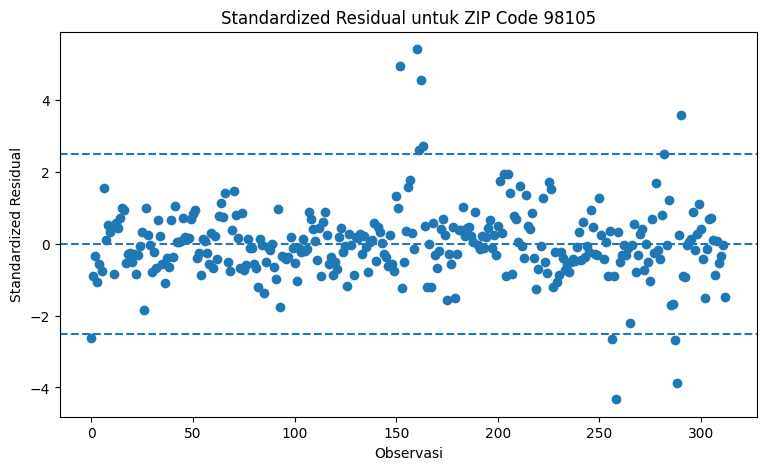

In [103]:
plt.figure(figsize=(9, 5))

plt.scatter(
    range(len(sresiduals)),
    sresiduals
)

plt.axhline(
    0,
    linestyle='--'
)

plt.axhline(
    2.5,
    linestyle='--'
)

plt.axhline(
    -2.5,
    linestyle='--'
)

plt.xlabel('Observasi')
plt.ylabel('Standardized Residual')
plt.title('Standardized Residual untuk ZIP Code 98105')

plt.show()

### Interpretasi Grafik

Grafik standardized residual membantu mengidentifikasi observasi yang jauh dari pola umum model.

Observasi yang berada jauh dari garis nol perlu diperiksa lebih lanjut.

Garis ±2,5 pada grafik digunakan sebagai panduan visual, bukan sebagai batas mutlak untuk menentukan apakah suatu observasi harus dianggap sebagai outlier.

### Ringkasan Outliers

- Outlier dalam regresi adalah observasi yang nilai aktualnya jauh dari nilai prediksi.
- Standardized residual digunakan untuk membandingkan besar residual antarobservasi.
- Nilai standardized residual menunjukkan jarak observasi dari garis regresi dalam satuan standard error.
- Residual yang sangat besar tidak otomatis berarti data harus dihapus.
- Penyebab outlier perlu diperiksa terlebih dahulu.
- Outlier dapat berasal dari kesalahan data, transaksi abnormal, atau kejadian yang memang tidak biasa.
- Dalam anomaly detection, observasi seperti ini justru dapat menjadi fokus utama analisis.

### 4.6.2 Influential Values

**Influential value** adalah observasi yang keberadaan atau ketidakberadaannya dapat menyebabkan perubahan besar pada persamaan regresi.

Observasi yang influential tidak selalu memiliki residual yang sangat besar.

Sebuah observasi dapat memiliki pengaruh besar karena posisinya sangat berbeda dari observasi lain pada ruang prediktor.

Konsep penting yang digunakan untuk mendeteksi influential observations adalah:

- **Leverage atau hat-value**
- **Cook's Distance**
- **Standardized residual**

#### Leverage

**Leverage** mengukur seberapa jauh nilai prediktor suatu observasi dari pola umum prediktor lainnya.

Observasi dengan leverage tinggi memiliki potensi untuk menarik atau mengubah posisi garis maupun bidang regresi.

Leverage sering diukur menggunakan **hat-value**.

Salah satu aturan praktis untuk mendeteksi leverage tinggi adalah:

$$
h_i > \frac{2(P+1)}{n}
$$

dengan:

- \(h_i\) = hat-value observasi ke-i
- \(P\) = jumlah prediktor
- \(n\) = jumlah observasi

In [104]:
# Menghitung ukuran influence

influence = OLSInfluence(result_98105)

hat_values = influence.hat_matrix_diag
studentized_residuals = influence.resid_studentized_internal
cooks_distance = influence.cooks_distance[0]

print("Jumlah observasi:", len(hat_values))

Jumlah observasi: 313


In [105]:
# Membuat tabel diagnostik influence

diagnostik_influence = pd.DataFrame({
    'Hat_Value': hat_values,
    'Studentized_Residual': studentized_residuals,
    'Cooks_Distance': cooks_distance
}, index=house_98105.index)

diagnostik_influence.head()

,Hat_Value,Studentized_Residual,Cooks_Distance
1036,0.050869,-2.622626,0.061440
1769,0.014388,-0.892439,0.001938
1770,0.009945,-0.354599,0.000211
1771,0.015435,-1.054669,0.002906
1783,0.018706,-0.563783,0.001010


In [106]:
diagnostik_influence = pd.concat(
    [
        house_98105[
            [
                'AdjSalePrice',
                'SqFtTotLiving',
                'SqFtLot',
                'Bathrooms',
                'Bedrooms',
                'BldgGrade'
            ]
        ],
        diagnostik_influence
    ],
    axis=1
)

diagnostik_influence.head()

,AdjSalePrice,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade,Hat_Value,Studentized_Residual,Cooks_Distance
1036,826139.0,4200,7245,4.50,6,8,0.050869,-2.622626,0.061440
1769,673255.0,1920,6750,1.75,4,8,0.014388,-0.892439,0.001938
1770,655878.0,1900,6630,1.75,3,7,0.009945,-0.354599,0.000211
1771,643754.0,2340,7130,1.75,3,7,0.015435,-1.054669,0.002906
1783,1345979.0,4010,8510,3.50,5,9,0.018706,-0.563783,0.001010


In [107]:
# Jumlah observasi dan prediktor

n = len(house_98105)
p = len(predictors_diag)

batas_leverage = 2 * (p + 1) / n

print(f"Batas leverage: {batas_leverage:.4f}")

Batas leverage: 0.0383


In [108]:
high_leverage = diagnostik_influence[
    diagnostik_influence['Hat_Value'] > batas_leverage
]

print("Jumlah observasi dengan leverage tinggi:")
print(len(high_leverage))

high_leverage.sort_values(
    'Hat_Value',
    ascending=False
).head(10)

Jumlah observasi dengan leverage tinggi:
19


,AdjSalePrice,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade,Hat_Value,Studentized_Residual,Cooks_Distance
26040,2266142.0,4930,25114,4.25,5,12,0.269738,-2.691342,0.445914
24382,765348.0,2820,4480,3.00,9,7,0.132587,0.556018,0.007876
2913,2147692.0,5120,16089,4.75,3,10,0.125138,-0.067092,0.000107
14384,3013254.0,4470,18407,3.00,5,11,0.121086,4.941992,0.560789
26043,2577930.0,4480,12600,5.75,5,11,0.095508,3.589718,0.226779
26036,1809836.0,5570,9600,3.25,5,9,0.086642,-0.027411,0.000012
26039,1358857.0,3340,14000,3.25,5,10,0.069817,-1.681947,0.035389
9253,686745.0,3110,4400,2.75,7,7,0.055777,-0.552971,0.003010
14393,1993561.0,4990,6398,3.50,6,9,0.055301,2.599780,0.065942
14341,1160465.0,4330,4000,3.50,4,9,0.051941,-1.168054,0.012458


### Interpretasi Leverage

Observasi dengan hat-value tinggi mempunyai kombinasi nilai prediktor yang relatif tidak biasa dibandingkan observasi lainnya.

Namun, leverage tinggi tidak otomatis berarti observasi tersebut merupakan outlier.

Observasi dengan leverage tinggi menjadi lebih penting jika juga memiliki residual yang cukup besar.

#### Cook's Distance

**Cook's Distance** mengukur seberapa besar perubahan model regresi jika suatu observasi dihilangkan.

Cook's Distance menggabungkan informasi dari:

- residual,
- dan leverage.

Nilai Cook's Distance yang besar menunjukkan bahwa suatu observasi memiliki pengaruh yang besar terhadap hasil estimasi model.

In [109]:
# Batas praktis Cook's Distance

batas_cook = 4 / (n - p - 1)

print(f"Batas Cook's Distance: {batas_cook:.4f}")

Batas Cook's Distance: 0.0130


In [110]:
high_cook = diagnostik_influence[
    diagnostik_influence['Cooks_Distance'] > batas_cook
]

print("Jumlah observasi dengan Cook's Distance tinggi:")
print(len(high_cook))

high_cook.sort_values(
    'Cooks_Distance',
    ascending=False
).head(10)

Jumlah observasi dengan Cook's Distance tinggi:
20


,AdjSalePrice,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade,Hat_Value,Studentized_Residual,Cooks_Distance
14384,3013254.0,4470,18407,3.00,5,11,0.121086,4.941992,0.560789
26040,2266142.0,4930,25114,4.25,5,12,0.269738,-2.691342,0.445914
26043,2577930.0,4480,12600,5.75,5,11,0.095508,3.589718,0.226779
24333,119748.0,2900,7276,3.00,6,7,0.037309,-4.326732,0.120919
14392,2296386.0,3630,7200,4.00,4,9,0.023492,5.408105,0.117267
26041,853924.0,4070,9095,2.75,3,9,0.043443,-3.883865,0.114180
14393,1993561.0,4990,6398,3.50,6,9,0.055301,2.599780,0.065942
1036,826139.0,4200,7245,4.50,6,8,0.050869,-2.622626,0.061440
14394,2095917.0,3760,5880,3.50,5,9,0.017149,4.549385,0.060188
24331,885902.0,3560,3750,3.25,3,10,0.042541,-2.646280,0.051857


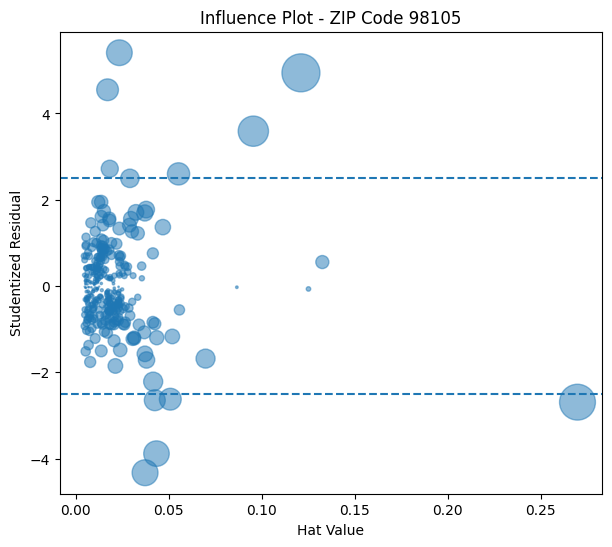

In [111]:
# Influence plot

fig, ax = plt.subplots(figsize=(7, 6))

ax.axhline(
    -2.5,
    linestyle='--'
)

ax.axhline(
    2.5,
    linestyle='--'
)

ax.scatter(
    hat_values,
    studentized_residuals,
    s=1000 * np.sqrt(cooks_distance),
    alpha=0.5
)

ax.set_xlabel('Hat Value')
ax.set_ylabel('Studentized Residual')
ax.set_title('Influence Plot - ZIP Code 98105')

plt.show()

### Interpretasi Influence Plot

Pada influence plot:

- sumbu X menunjukkan **hat-value atau leverage**,
- sumbu Y menunjukkan **studentized residual**,
- ukuran lingkaran menunjukkan besar **Cook's Distance**.

Observasi dengan lingkaran besar merupakan observasi yang memiliki pengaruh lebih besar terhadap model.

Observasi yang sekaligus memiliki leverage tinggi dan residual besar perlu diperiksa lebih lanjut.

In [112]:
# Observasi yang sangat influential
# menggunakan batas pada contoh buku

influential_008 = diagnostik_influence[
    diagnostik_influence['Cooks_Distance'] > 0.08
]

print("Jumlah observasi dengan Cook's Distance > 0.08:")
print(len(influential_008))

influential_008.sort_values(
    'Cooks_Distance',
    ascending=False
)

Jumlah observasi dengan Cook's Distance > 0.08:
6


,AdjSalePrice,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade,Hat_Value,Studentized_Residual,Cooks_Distance
14384,3013254.0,4470,18407,3.00,5,11,0.121086,4.941992,0.560789
26040,2266142.0,4930,25114,4.25,5,12,0.269738,-2.691342,0.445914
26043,2577930.0,4480,12600,5.75,5,11,0.095508,3.589718,0.226779
24333,119748.0,2900,7276,3.00,6,7,0.037309,-4.326732,0.120919
14392,2296386.0,3630,7200,4.00,4,9,0.023492,5.408105,0.117267
26041,853924.0,4070,9095,2.75,3,9,0.043443,-3.883865,0.114180


In [113]:
# Memilih observasi dengan Cook's Distance <= 0.08

mask_tanpa_influential = (
    cooks_distance <= 0.08
)

house_98105_clean = house_98105.loc[
    mask_tanpa_influential
].copy()

print(
    "Jumlah data awal:",
    len(house_98105)
)

print(
    "Jumlah data setelah observasi influential dihapus:",
    len(house_98105_clean)
)

Jumlah data awal: 313
Jumlah data setelah observasi influential dihapus: 307


In [115]:
# Model setelah influential observations dihapus

X_clean = house_98105_clean[
    predictors_diag
].assign(const=1)

y_clean = house_98105_clean[
    outcome_diag
]

model_clean = sm.OLS(
    y_clean,
    X_clean
)

result_clean = model_clean.fit()

In [116]:
perbandingan_influence = pd.DataFrame({
    'Model_Awal': result_98105.params,
    'Influential_Dihapus': result_clean.params
})

perbandingan_influence

,Model_Awal,Influential_Dihapus
SqFtTotLiving,209.602346,230.052569
SqFtLot,38.933315,33.141600
Bathrooms,2282.264145,-16131.879785
Bedrooms,-26320.268796,-22887.865318
BldgGrade,130000.099737,114870.559737
const,-772549.862447,-647137.096716


### Interpretasi Pengaruh Observasi Influential

Setelah observasi dengan Cook's Distance besar dihapus, beberapa koefisien regresi berubah.

Hal ini menunjukkan bahwa sejumlah observasi memiliki pengaruh yang cukup besar terhadap bentuk persamaan regresi.

Perubahan koefisien yang besar menunjukkan bahwa hasil model sebelumnya cukup sensitif terhadap keberadaan observasi tertentu.

Namun, observasi influential tidak boleh otomatis dihapus.

Observasi tersebut harus diperiksa terlebih dahulu untuk menentukan apakah:

- terjadi kesalahan pencatatan,
- observasi berasal dari kondisi yang tidak biasa,
- atau observasi tersebut memang merupakan data valid yang penting.

### Perbedaan Outlier dan Influential Value

**Outlier**

Observasi dengan nilai aktual yang jauh dari nilai prediksi model.

Biasanya terlihat melalui residual atau standardized residual yang besar.

**Influential Value**

Observasi yang keberadaan atau penghapusannya dapat menyebabkan perubahan besar terhadap persamaan regresi.

Observasi influential sering mempunyai leverage tinggi, Cook's Distance besar, atau kombinasi keduanya.

Dengan demikian, sebuah outlier belum tentu influential dan sebuah influential observation belum tentu memiliki residual yang sangat besar.

### Ringkasan Influential Values

- Influential observation adalah observasi yang dapat mengubah hasil regresi secara signifikan.
- Leverage menunjukkan seberapa tidak biasa posisi suatu observasi berdasarkan nilai prediktornya.
- Hat-value digunakan untuk mengukur leverage.
- Cook's Distance menggabungkan leverage dan ukuran residual.
- Influence plot menampilkan leverage, standardized residual, dan Cook's Distance secara bersamaan.
- Observasi influential tidak boleh langsung dihapus tanpa pemeriksaan lebih lanjut.
- Pada dataset kecil, influential observations dapat memberikan dampak besar terhadap estimasi koefisien.

### 4.6.3 Heteroskedasticity, Non-Normality, dan Correlated Errors

Analisis residual digunakan untuk memahami apakah terdapat pola tertentu yang belum berhasil dijelaskan oleh model regresi.

Dalam regresi klasik, residual biasanya diasumsikan:

1. memiliki distribusi yang mendekati normal,
2. memiliki varians yang relatif konstan,
3. dan saling independen.

Pelanggaran terhadap asumsi tersebut tidak selalu membuat model tidak berguna untuk prediksi.

Namun, pola tertentu pada residual dapat menunjukkan bahwa model masih kehilangan informasi penting.

#### Heteroskedasticity

**Heteroskedasticity** terjadi ketika varians residual tidak konstan pada seluruh rentang nilai prediksi.

Dengan kata lain, besar kesalahan prediksi berbeda pada bagian-bagian tertentu dari rentang prediksi.

Contohnya:

- model mungkin memiliki error kecil untuk rumah dengan harga menengah,
- tetapi memiliki error yang jauh lebih besar untuk rumah dengan harga sangat tinggi.

Pola seperti ini dapat menunjukkan bahwa model belum menangkap seluruh informasi yang memengaruhi variabel respons.

In [117]:
import seaborn as sns

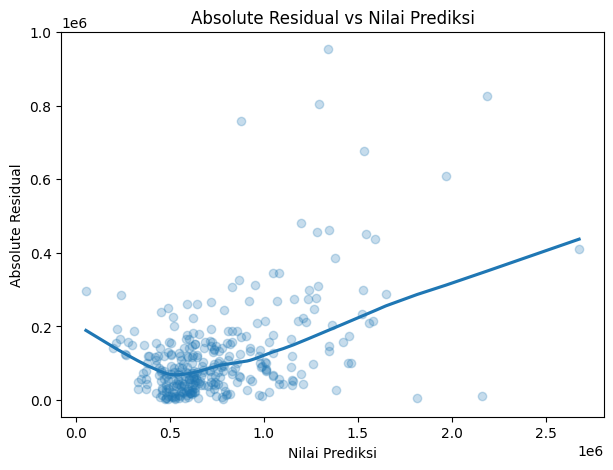

In [118]:
# Membuat plot nilai prediksi terhadap absolute residual

fig, ax = plt.subplots(figsize=(7, 5))

sns.regplot(
    x=result_98105.fittedvalues,
    y=np.abs(result_98105.resid),
    scatter_kws={'alpha': 0.25},
    lowess=True,
    ax=ax
)

ax.set_xlabel('Nilai Prediksi')
ax.set_ylabel('Absolute Residual')
ax.set_title('Absolute Residual vs Nilai Prediksi')

plt.show()

### Interpretasi Plot Heteroskedasticity

Jika penyebaran residual relatif sama pada seluruh nilai prediksi, maka varians residual dapat dianggap relatif konstan.

Sebaliknya, jika ukuran residual berubah secara sistematis ketika nilai prediksi meningkat atau menurun, terdapat indikasi heteroskedasticity.

Pada data rumah ZIP Code 98105, buku menunjukkan bahwa varians residual cenderung berbeda pada berbagai rentang harga rumah.

Hal ini menunjukkan bahwa besar kesalahan prediksi model tidak seragam untuk seluruh nilai rumah.

### Mengapa Heteroskedasticity Penting?

Dalam konteks data science, heteroskedasticity penting karena dapat menunjukkan bahwa error prediksi berbeda pada kelompok data tertentu.

Hal ini dapat berarti bahwa model belum memasukkan variabel atau pola tertentu yang penting.

Sebagai contoh, error yang lebih besar pada rumah dengan harga sangat tinggi dapat menunjukkan bahwa model linear sederhana belum cukup menjelaskan karakteristik rumah mewah.

Dengan demikian, pemeriksaan heteroskedasticity dapat membantu menemukan struktur data yang belum ditangkap model.

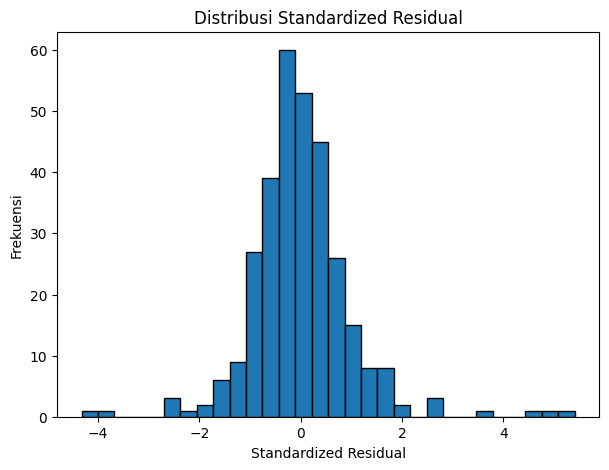

In [119]:
# Histogram standardized residual

plt.figure(figsize=(7, 5))

plt.hist(
    studentized_residuals,
    bins=30,
    edgecolor='black'
)

plt.xlabel('Standardized Residual')
plt.ylabel('Frekuensi')
plt.title('Distribusi Standardized Residual')

plt.show()

#### Non-Normal Residuals

Residual dikatakan non-normal jika distribusinya berbeda secara jelas dari distribusi normal.

Penyimpangan dapat terlihat dalam bentuk:

- skewness,
- ekor distribusi yang panjang,
- atau banyak nilai ekstrem.

Distribusi residual yang tidak normal dapat menunjukkan bahwa model belum sepenuhnya menangkap struktur data.

Namun, dalam predictive modeling, normalitas residual biasanya tidak menjadi perhatian utama selama performa prediksi model tetap baik.

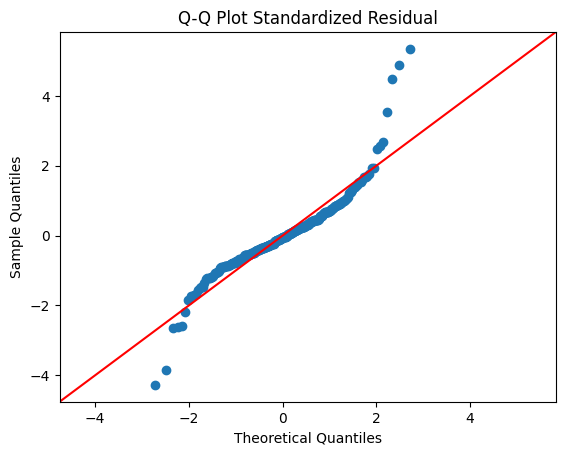

In [120]:
# Q-Q plot untuk memeriksa normalitas residual

sm.qqplot(
    studentized_residuals,
    line='45',
    fit=True
)

plt.title('Q-Q Plot Standardized Residual')
plt.show()

### Interpretasi Q-Q Plot

Pada Q-Q plot:

- titik yang mengikuti garis diagonal menunjukkan distribusi yang mendekati normal,
- penyimpangan besar dari garis diagonal menunjukkan kemungkinan non-normality.

Perhatian khusus dapat diberikan pada bagian ekor distribusi karena outlier sering menyebabkan penyimpangan terbesar pada area tersebut.

#### Correlated Errors

Residual disebut **correlated errors** ketika error suatu observasi berkaitan dengan error observasi lainnya.

Masalah ini sering muncul pada data yang dikumpulkan berdasarkan:

- waktu,
- atau lokasi.

Sebagai contoh pada time series, residual hari ini dapat berkaitan dengan residual hari sebelumnya.

Jika pola tersebut terjadi, berarti masih terdapat informasi sistematis yang belum dimasukkan ke dalam model.

In [121]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(
    result_98105.resid
)

print(
    f"Durbin-Watson Statistic: {dw:.4f}"
)

Durbin-Watson Statistic: 1.5078


### Durbin-Watson Statistic

Durbin-Watson statistic digunakan untuk membantu mendeteksi autocorrelation pada residual.

Statistik ini terutama relevan untuk data yang memiliki urutan waktu.

Pada dataset rumah yang digunakan di sini, observasi bukan contoh time series sederhana sehingga nilai Durbin-Watson tidak menjadi fokus utama analisis.

Konsep ini lebih penting ketika regresi diterapkan pada data yang dikumpulkan secara berurutan dari waktu ke waktu.

### Ringkasan Diagnostik Residual

**Heteroskedasticity**

Varians residual berubah pada berbagai rentang nilai prediksi.

**Non-Normal Residuals**

Distribusi residual tidak mengikuti bentuk distribusi normal.

**Correlated Errors**

Residual suatu observasi memiliki hubungan dengan residual observasi lainnya.

Dalam data science, pelanggaran asumsi tersebut tidak selalu berarti model harus dibuang.

Namun, pola residual dapat memberikan petunjuk bahwa model belum menangkap seluruh informasi yang tersedia dalam data.

### Kesimpulan

- Residual dapat digunakan untuk mengevaluasi kelemahan model regresi.
- Heteroskedasticity menunjukkan varians error yang tidak konstan.
- Non-normal residual dapat menunjukkan distribusi error yang memiliki skewness atau ekor panjang.
- Correlated errors menunjukkan bahwa residual tidak independen.
- Masalah residual terutama penting untuk inferensi statistik, tetapi juga dapat membantu menemukan pola yang belum ditangkap oleh model prediktif.
- Visualisasi residual merupakan salah satu cara paling praktis untuk melakukan regression diagnostics.

### 4.6.4 Partial Residual Plots dan Nonlinearity

**Partial residual plot** digunakan untuk mengevaluasi hubungan antara satu variabel prediktor dan variabel respons dengan tetap mempertimbangkan prediktor lain dalam model.

Partial residual dapat dipandang sebagai nilai respons sintetis yang menggabungkan:

- residual dari model lengkap,
- dan kontribusi dari satu prediktor tertentu.

Untuk prediktor \(X_i\), partial residual dapat ditulis sebagai:

$$
Partial\ Residual
=
Residual + b_iX_i
$$

dengan:

- \(b_i\) = koefisien regresi prediktor \(X_i\),
- \(X_i\) = nilai prediktor,
- Residual = selisih antara nilai aktual dan nilai prediksi model.

Partial residual plot membantu melihat apakah hubungan antara suatu prediktor dan respons benar-benar linear.

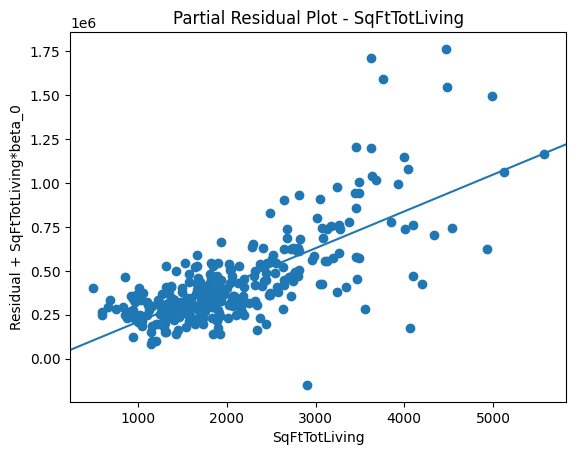

In [122]:
# Membuat partial residual plot
# untuk SqFtTotLiving

sm.graphics.plot_ccpr(
    result_98105,
    'SqFtTotLiving'
)

plt.title(
    'Partial Residual Plot - SqFtTotLiving'
)

plt.show()

### Interpretasi Partial Residual Plot

Pada partial residual plot:

- sumbu X menunjukkan nilai `SqFtTotLiving`,
- sumbu Y menunjukkan partial residual,
- garis linear menunjukkan hubungan yang diasumsikan oleh model regresi.

Jika pola titik mengikuti garis linear dengan baik, hubungan antara prediktor dan respons dapat dianggap cukup linear.

Jika terlihat pola melengkung atau sistematis yang menyimpang dari garis linear, hal tersebut menunjukkan kemungkinan adanya hubungan nonlinier.

### Nonlinearity pada SqFtTotLiving

Partial residual plot menunjukkan bahwa hubungan antara luas tempat tinggal dan harga rumah tidak sepenuhnya linear.

Model linear cenderung:

- **underestimate** harga rumah dengan luas kurang dari sekitar 1.000 square feet,
- **overestimate** harga rumah dengan luas sekitar 2.000 sampai 3.000 square feet.

Untuk rumah dengan luas di atas sekitar 4.000 square feet, jumlah observasi terlalu sedikit untuk menarik kesimpulan yang kuat.

### Mengapa Hubungan Dapat Bersifat Nonlinear?

Pengaruh tambahan luas rumah tidak selalu sama pada seluruh ukuran rumah.

Sebagai contoh, tambahan 500 square feet pada rumah kecil dapat memberikan perubahan nilai yang lebih besar dibandingkan tambahan 500 square feet pada rumah yang sudah sangat besar.

Dengan demikian, hubungan antara luas rumah dan harga tidak harus mengikuti satu garis lurus pada seluruh rentang data.

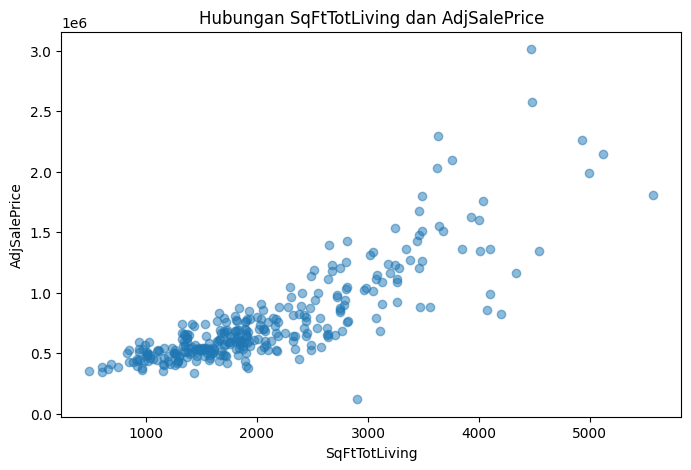

In [123]:
# Hubungan langsung SqFtTotLiving dengan AdjSalePrice
# pada ZIP Code 98105

plt.figure(figsize=(8, 5))

plt.scatter(
    house_98105['SqFtTotLiving'],
    house_98105['AdjSalePrice'],
    alpha=0.5
)

plt.xlabel('SqFtTotLiving')
plt.ylabel('AdjSalePrice')
plt.title(
    'Hubungan SqFtTotLiving dan AdjSalePrice'
)

plt.show()

In [124]:
# Mengambil koefisien SqFtTotLiving

coef_sqft = result_98105.params[
    'SqFtTotLiving'
]

# Menghitung partial residual

partial_residual_sqft = (
    result_98105.resid
    +
    coef_sqft * house_98105['SqFtTotLiving']
)

partial_residual_sqft.head()

,0
1036,424267.621513
1769,244291.301245
1770,335266.129986
1771,303675.472487
1783,740818.873653


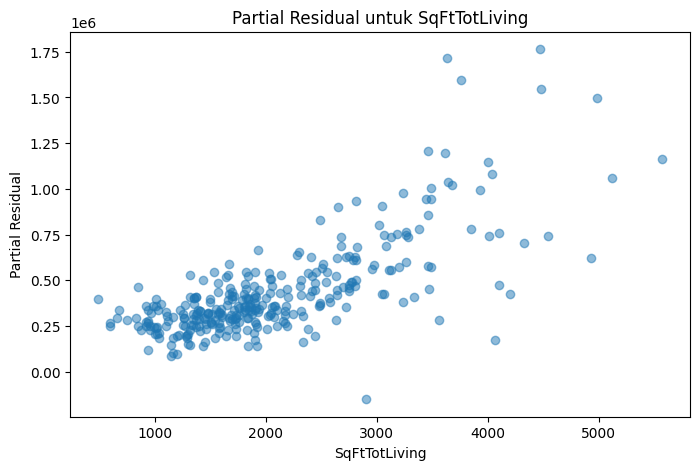

In [125]:
plt.figure(figsize=(8, 5))

plt.scatter(
    house_98105['SqFtTotLiving'],
    partial_residual_sqft,
    alpha=0.5
)

plt.xlabel('SqFtTotLiving')
plt.ylabel('Partial Residual')
plt.title(
    'Partial Residual untuk SqFtTotLiving'
)

plt.show()

### Interpretasi Partial Residual

Partial residual menggabungkan residual model dengan kontribusi prediktor yang sedang dianalisis.

Dengan pendekatan ini, hubungan `SqFtTotLiving` dengan harga rumah dapat dilihat setelah pengaruh prediktor lain dalam model diperhitungkan.

Jika pola partial residual tidak mengikuti hubungan linear, model dapat diperbaiki dengan menggunakan bentuk hubungan yang lebih fleksibel.

### Implikasi terhadap Pemodelan

Jika partial residual plot menunjukkan pola nonlinear, model linear sederhana mungkin tidak cukup untuk menggambarkan hubungan data.

Beberapa pendekatan yang dapat digunakan antara lain:

- polynomial regression,
- spline regression,
- generalized additive models.

Pendekatan tersebut memungkinkan hubungan antara prediktor dan respons mengikuti bentuk yang lebih fleksibel daripada garis lurus.

### Ringkasan Regression Diagnostics

- Outlier adalah observasi dengan nilai aktual yang jauh dari nilai prediksi.
- Standardized residual membantu mengidentifikasi observasi ekstrem.
- Influential observation dapat menyebabkan perubahan besar pada persamaan regresi.
- Leverage dan Cook's Distance digunakan untuk mengukur pengaruh observasi.
- Heteroskedasticity menunjukkan varians residual yang tidak konstan.
- Non-normal residual dapat menunjukkan pola yang belum ditangkap model.
- Correlated errors menunjukkan residual yang tidak independen.
- Partial residual plot membantu mengevaluasi hubungan antara satu prediktor dan respons setelah memperhitungkan prediktor lainnya.
- Pola nonlinear pada partial residual dapat menjadi alasan untuk menggunakan model yang lebih fleksibel.

## 4.7 Polynomial and Spline Regression

Hubungan antara variabel prediktor dan variabel respons tidak selalu bersifat linear.

Sebagai contoh:

- peningkatan dosis obat tidak selalu menghasilkan peningkatan respons dengan proporsi yang sama,
- peningkatan biaya pemasaran tidak selalu menghasilkan peningkatan permintaan secara linear,
- pengaruh luas rumah terhadap harga dapat berubah pada ukuran rumah yang berbeda.

Beberapa pendekatan yang dapat digunakan untuk menangkap hubungan nonlinear adalah:

- Polynomial Regression
- Spline Regression
- Generalized Additive Models (GAM)

### Istilah Penting

**Polynomial Regression**

Regresi yang menambahkan bentuk pangkat dari prediktor, seperti \(X^2\), \(X^3\), dan seterusnya.

**Spline Regression**

Regresi yang membentuk kurva menggunakan beberapa segmen polinomial.

**Knots**

Titik yang memisahkan segmen-segmen pada spline.

**Generalized Additive Model (GAM)**

Model fleksibel yang dapat menggunakan fungsi smooth atau spline untuk menangkap hubungan nonlinear.

### 4.7.1 Polynomial Regression

Polynomial regression memperluas regresi linear dengan menambahkan bentuk pangkat dari variabel prediktor.

Sebagai contoh, regresi kuadratik dapat ditulis sebagai:

$$
Y =
b_0 +
b_1X +
b_2X^2 +
e
$$

Model memiliki dua komponen untuk variabel \(X\):

- \(X\) sebagai komponen linear,
- \(X^2\) sebagai komponen kuadratik.

Penambahan \(X^2\) memungkinkan hubungan antara X dan Y membentuk kurva, sehingga model tidak harus mengikuti satu garis lurus.

In [126]:
# Membuat model polynomial orde 2
# untuk SqFtTotLiving

model_poly = smf.ols(
    formula=(
        'AdjSalePrice ~ '
        'SqFtTotLiving + '
        'I(SqFtTotLiving**2) + '
        'SqFtLot + Bathrooms + '
        'Bedrooms + BldgGrade'
    ),
    data=house_98105
)

result_poly = model_poly.fit()

result_poly.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           AdjSalePrice   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.802
Method:                 Least Squares   F-statistic:                     211.6
Date:                Sat, 03 Oct 2026   Prob (F-statistic):          9.95e-106
Time:                        12:18:51   Log-Likelihood:                -4217.9
No. Observations:                 313   AIC:                             8450.
Df Residuals:                     306   BIC:                             8476.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept             -6.159e+05   1.03e+05     -5.953      0.000   -8.19e+05   -4.12e+05
SqFtTotLiving             7.4521     55.418      0.134      0.893    -101.597     116.501
I(SqFtTotLiving ** 2)     0.0388      0.010      4.040      0.000       0.020       0.058
SqFtLot                  32.5594      5.436      5.990      0.000      21.863      43.256
Bathrooms             -1435.1231   1.95e+04     -0.074      0.941   -3.99e+04     3.7e+04
Bedrooms              -9191.9441   1.33e+04     -0.693      0.489   -3.53e+04    1.69e+04
BldgGrade              1.357e+05   1.49e+04      9.087      0.000    1.06e+05    1.65e+05
==============================================================================
Omnibus:                       75.161   Durbin-Watson:                   1.625
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              637.978
Skew:                           0.699   Prob(JB):                    2.92e-139
Kurtosis:                       9.853   Cond. No.                     7.37e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.37e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [127]:
print("Koefisien model polynomial:\n")

for nama, nilai in result_poly.params.items():
    print(f"{nama}: {nilai:.3f}")

Koefisien model polynomial:

Intercept: -615850.842
SqFtTotLiving: 7.452
I(SqFtTotLiving ** 2): 0.039
SqFtLot: 32.559
Bathrooms: -1435.123
Bedrooms: -9191.944
BldgGrade: 135717.060


### Interpretasi Koefisien Polynomial

Sekarang terdapat dua koefisien yang berkaitan dengan `SqFtTotLiving`:

1. koefisien untuk \(SqFtTotLiving\),
2. koefisien untuk \(SqFtTotLiving^2\).

Karena terdapat komponen kuadrat, pengaruh tambahan luas rumah terhadap harga tidak lagi dianggap konstan pada seluruh ukuran rumah.

Besarnya perubahan harga bergantung pada nilai `SqFtTotLiving` itu sendiri.

Oleh karena itu, koefisien polynomial sebaiknya tidak diinterpretasikan secara terpisah seperti koefisien pada regresi linear sederhana.

In [128]:
print("Model Linear")
print(f"R²          : {result_98105.rsquared:.4f}")
print(f"Adjusted R² : {result_98105.rsquared_adj:.4f}")
print(f"AIC         : {result_98105.aic:.2f}")

print("\nModel Polynomial")
print(f"R²          : {result_poly.rsquared:.4f}")
print(f"Adjusted R² : {result_poly.rsquared_adj:.4f}")
print(f"AIC         : {result_poly.aic:.2f}")

Model Linear
R²          : 0.7954
Adjusted R² : 0.7921
AIC         : 8463.98

Model Polynomial
R²          : 0.8058
Adjusted R² : 0.8020
AIC         : 8449.72


### Perbandingan Model

Model polynomial memiliki fleksibilitas lebih tinggi dibandingkan model linear karena dapat menangkap curvature.

Perbandingan dapat dilakukan menggunakan:

- R²,
- Adjusted R²,
- AIC,
- serta pola residual.

Namun, model yang lebih kompleks tidak otomatis menjadi model terbaik.

Peningkatan kecocokan model perlu dipertimbangkan bersama kompleksitas dan kemampuan model melakukan prediksi pada data baru.

In [129]:
# Membuat rentang SqFtTotLiving

sqft_grid = np.linspace(
    house_98105['SqFtTotLiving'].min(),
    house_98105['SqFtTotLiving'].max(),
    200
)

# Membuat data untuk prediksi
grid_poly = pd.DataFrame({
    'SqFtTotLiving': sqft_grid,
    'SqFtLot': house_98105['SqFtLot'].median(),
    'Bathrooms': house_98105['Bathrooms'].median(),
    'Bedrooms': house_98105['Bedrooms'].median(),
    'BldgGrade': house_98105['BldgGrade'].median()
})

# Prediksi model polynomial
pred_poly = result_poly.predict(grid_poly)

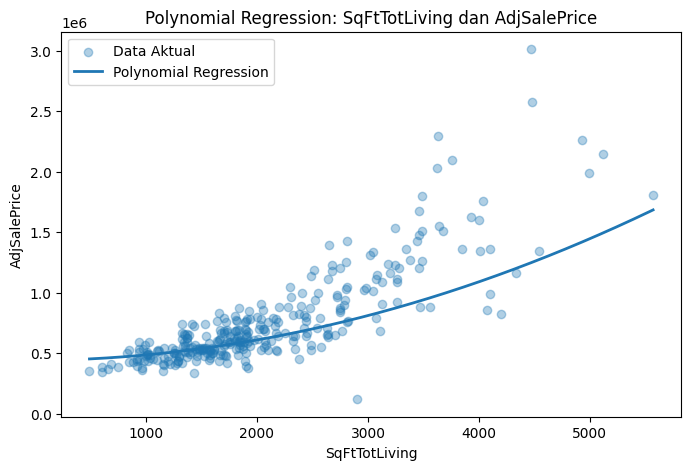

In [130]:
plt.figure(figsize=(8, 5))

plt.scatter(
    house_98105['SqFtTotLiving'],
    house_98105['AdjSalePrice'],
    alpha=0.35,
    label='Data Aktual'
)

plt.plot(
    sqft_grid,
    pred_poly,
    linewidth=2,
    label='Polynomial Regression'
)

plt.xlabel('SqFtTotLiving')
plt.ylabel('AdjSalePrice')
plt.title('Polynomial Regression: SqFtTotLiving dan AdjSalePrice')
plt.legend()

plt.show()

### Keterbatasan Polynomial Regression

Polynomial regression dapat dibuat semakin fleksibel dengan menambahkan:

$$
X^3,\ X^4,\ X^5,\ ...
$$

Namun, polynomial dengan orde yang terlalu tinggi dapat menghasilkan kurva yang terlalu berfluktuasi atau **wiggly**.

Model seperti itu dapat mengikuti noise dalam data dan menghasilkan pola yang tidak realistis.

Karena itu, polynomial berorde tinggi tidak selalu menjadi pilihan terbaik untuk menangkap hubungan nonlinear.

### Ringkasan Polynomial Regression

- Hubungan antara prediktor dan respons tidak selalu linear.
- Polynomial regression menambahkan pangkat prediktor ke dalam model.
- Model kuadratik menggunakan \(X\) dan \(X^2\).
- Komponen polynomial memungkinkan model menangkap pola melengkung.
- Pada King County Housing Data, polynomial digunakan untuk memodelkan hubungan nonlinear antara SqFtTotLiving dan AdjSalePrice.
- Polynomial dengan orde terlalu tinggi dapat menghasilkan model yang terlalu berfluktuasi.
- Splines memberikan alternatif yang lebih fleksibel untuk memodelkan hubungan nonlinear.

### 4.7.2 Spline Regression

Polynomial regression dapat menangkap hubungan nonlinear, tetapi penggunaan polynomial dengan orde tinggi dapat menghasilkan kurva yang terlalu berfluktuasi.

Alternatif yang lebih fleksibel adalah **spline regression**.

Spline membentuk hubungan nonlinear menggunakan beberapa segmen polinomial yang disambungkan secara halus.

Titik tempat segmen-segmen tersebut bertemu disebut **knots**.

Secara umum, spline memungkinkan model mengikuti pola nonlinear tanpa harus menggunakan satu polynomial berorde sangat tinggi.

#### Knots

**Knots** adalah titik pada variabel prediktor yang digunakan untuk membagi hubungan menjadi beberapa segmen polynomial.

Setiap segmen memiliki bentuk polynomial sendiri, tetapi segmen-segmen tersebut disambungkan secara halus.

Jumlah dan posisi knots menentukan tingkat fleksibilitas spline.

Semakin banyak knots, semakin fleksibel bentuk kurva yang dapat dihasilkan.

In [131]:
from patsy import bs

In [132]:
# Membuat model spline

formula_spline = (
    'AdjSalePrice ~ '
    'bs(SqFtTotLiving, df=6, degree=3) + '
    'SqFtLot + Bathrooms + Bedrooms + BldgGrade'
)

model_spline = smf.ols(
    formula=formula_spline,
    data=house_98105
)

result_spline = model_spline.fit()

result_spline.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           AdjSalePrice   R-squared:                       0.814
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     131.8
Date:                Sat, 03 Oct 2026   Prob (F-statistic):          7.10e-104
Time:                        12:25:01   Log-Likelihood:                -4211.4
No. Observations:                 313   AIC:                             8445.
Df Residuals:                     302   BIC:                             8486.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
========================================================================================================
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
Intercept                            -4.142e+05   1.43e+05     -2.899      0.004   -6.95e+05   -1.33e+05
bs(SqFtTotLiving, df=6, degree=3)[0] -1.995e+05   1.86e+05     -1.076      0.283   -5.65e+05    1.66e+05
bs(SqFtTotLiving, df=6, degree=3)[1] -1.206e+05   1.23e+05     -0.983      0.326   -3.62e+05    1.21e+05
bs(SqFtTotLiving, df=6, degree=3)[2] -7.164e+04   1.36e+05     -0.525      0.600    -3.4e+05    1.97e+05
bs(SqFtTotLiving, df=6, degree=3)[3]  1.957e+05   1.62e+05      1.212      0.227   -1.22e+05    5.14e+05
bs(SqFtTotLiving, df=6, degree=3)[4]  8.452e+05   2.18e+05      3.878      0.000    4.16e+05    1.27e+06
bs(SqFtTotLiving, df=6, degree=3)[5]  6.955e+05   2.14e+05      3.255      0.001    2.75e+05    1.12e+06
SqFtLot                                 33.3258      5.454      6.110      0.000      22.592      44.059
Bathrooms                            -4778.2080   1.94e+04     -0.246      0.806    -4.3e+04    3.34e+04
Bedrooms                             -5778.7045   1.32e+04     -0.437      0.663   -3.18e+04    2.03e+04
BldgGrade                             1.345e+05   1.52e+04      8.842      0.000    1.05e+05    1.64e+05
==============================================================================
Omnibus:                       58.816   Durbin-Watson:                   1.633
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              622.021
Skew:                           0.330   Prob(JB):                    8.51e-136
Kurtosis:                       9.874   Cond. No.                     1.97e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.97e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [133]:
print("Koefisien model spline:\n")

for nama, nilai in result_spline.params.items():
    print(f"{nama}: {nilai:.3f}")

Koefisien model spline:

Intercept: -414157.614
bs(SqFtTotLiving, df=6, degree=3)[0]: -199529.756
bs(SqFtTotLiving, df=6, degree=3)[1]: -120580.638
bs(SqFtTotLiving, df=6, degree=3)[2]: -71644.394
bs(SqFtTotLiving, df=6, degree=3)[3]: 195677.895
bs(SqFtTotLiving, df=6, degree=3)[4]: 845244.251
bs(SqFtTotLiving, df=6, degree=3)[5]: 695545.668
SqFtLot: 33.326
Bathrooms: -4778.208
Bedrooms: -5778.705
BldgGrade: 134462.374


### Interpretasi Koefisien Spline

Tidak seperti regresi linear, koefisien individual pada spline tidak memiliki interpretasi langsung yang sederhana.

Hal ini terjadi karena beberapa basis spline bekerja bersama-sama untuk membentuk kurva.

Oleh karena itu, spline biasanya lebih mudah diinterpretasikan melalui:

- grafik hasil prediksi,
- bentuk kurva,
- dan performa model,

daripada melalui masing-masing koefisien.

In [134]:
perbandingan_model = pd.DataFrame({
    'Model': [
        'Linear',
        'Polynomial',
        'Spline'
    ],
    'R-squared': [
        result_98105.rsquared,
        result_poly.rsquared,
        result_spline.rsquared
    ],
    'Adjusted R-squared': [
        result_98105.rsquared_adj,
        result_poly.rsquared_adj,
        result_spline.rsquared_adj
    ],
    'AIC': [
        result_98105.aic,
        result_poly.aic,
        result_spline.aic
    ]
})

perbandingan_model

,Model,R-squared,Adjusted R-squared,AIC
0,Linear,0.795426,0.792094,8463.984887
1,Polynomial,0.805785,0.801977,8449.720183
2,Spline,0.813584,0.807412,8444.890860


### Perbandingan Model

Spline memiliki fleksibilitas lebih besar dibandingkan model linear maupun polynomial kuadratik.

Namun, model yang lebih fleksibel tidak otomatis menjadi model terbaik.

Evaluasi tetap perlu mempertimbangkan:

- performa model,
- kompleksitas model,
- interpretasi,
- dan kemampuan model melakukan generalisasi pada data baru.

In [136]:
# Membuat rentang SqFtTotLiving

sqft_grid = np.linspace(
    house_98105['SqFtTotLiving'].min(),
    house_98105['SqFtTotLiving'].max(),
    200
)

grid_spline = pd.DataFrame({
    'SqFtTotLiving': sqft_grid,
    'SqFtLot': house_98105['SqFtLot'].median(),
    'Bathrooms': house_98105['Bathrooms'].median(),
    'Bedrooms': house_98105['Bedrooms'].median(),
    'BldgGrade': house_98105['BldgGrade'].median()
})

pred_spline = result_spline.predict(
    grid_spline
)

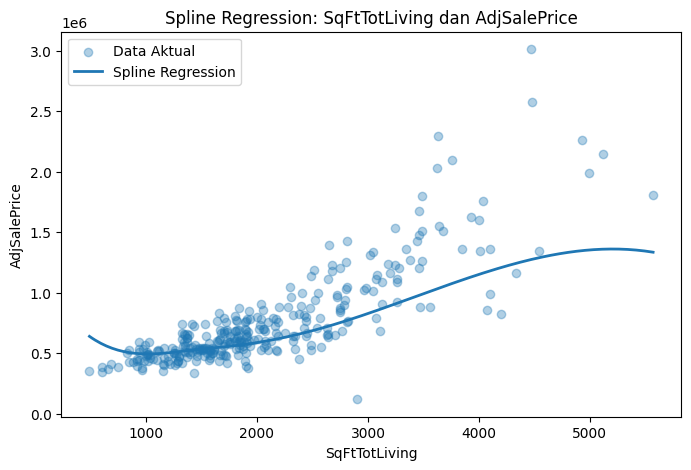

In [137]:
plt.figure(figsize=(8, 5))

plt.scatter(
    house_98105['SqFtTotLiving'],
    house_98105['AdjSalePrice'],
    alpha=0.35,
    label='Data Aktual'
)

plt.plot(
    sqft_grid,
    pred_spline,
    linewidth=2,
    label='Spline Regression'
)

plt.xlabel('SqFtTotLiving')
plt.ylabel('AdjSalePrice')
plt.title('Spline Regression: SqFtTotLiving dan AdjSalePrice')
plt.legend()

plt.show()

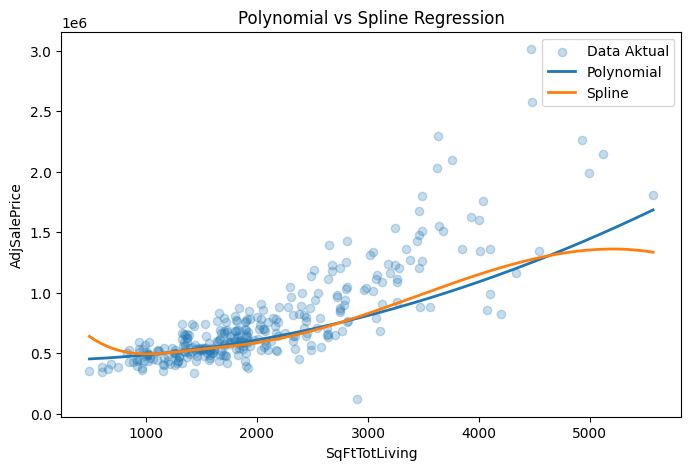

In [138]:
plt.figure(figsize=(8, 5))

plt.scatter(
    house_98105['SqFtTotLiving'],
    house_98105['AdjSalePrice'],
    alpha=0.25,
    label='Data Aktual'
)

plt.plot(
    sqft_grid,
    pred_poly,
    linewidth=2,
    label='Polynomial'
)

plt.plot(
    sqft_grid,
    pred_spline,
    linewidth=2,
    label='Spline'
)

plt.xlabel('SqFtTotLiving')
plt.ylabel('AdjSalePrice')
plt.title('Polynomial vs Spline Regression')
plt.legend()

plt.show()

### Polynomial vs Spline

Polynomial regression menggunakan satu fungsi polynomial untuk seluruh rentang prediktor.

Spline regression menggunakan beberapa segmen polynomial yang disambungkan secara halus.

Karena itu, spline dapat menyesuaikan bentuk hubungan lokal dengan lebih fleksibel dibandingkan polynomial sederhana.

### Keterbatasan Spline

Spline yang lebih fleksibel dapat mengikuti data dengan lebih dekat.

Namun, kecocokan yang lebih baik terhadap data training tidak selalu berarti model tersebut lebih benar.

Kurva yang dihasilkan tetap harus dievaluasi berdasarkan:

- konteks masalah,
- distribusi data,
- kemungkinan confounding variables,
- serta performa pada data baru.

Model yang terlalu fleksibel juga berpotensi mengikuti noise dalam data.

### Ringkasan Spline Regression

- Spline digunakan untuk memodelkan hubungan nonlinear secara fleksibel.
- Spline terdiri dari beberapa segmen polynomial.
- Segmen spline bertemu pada titik yang disebut knots.
- Cubic spline menggunakan polynomial derajat 3.
- B-spline dapat dibuat menggunakan fungsi `bs()`.
- Koefisien individual spline tidak memiliki interpretasi langsung yang sederhana.
- Spline biasanya diinterpretasikan melalui bentuk kurva dan performa model.
- Model yang lebih fleksibel tidak otomatis lebih baik dan tetap perlu divalidasi.

### 4.7.3 Generalized Additive Models (GAM)

**Generalized Additive Model (GAM)** adalah pendekatan regresi fleksibel yang dapat digunakan untuk memodelkan hubungan nonlinear antara prediktor dan variabel respons.

GAM berguna ketika:

- hubungan antara prediktor dan respons diduga nonlinear,
- polynomial regression kurang fleksibel,
- dan penentuan knots pada spline secara manual menjadi sulit.

Secara konseptual, GAM dapat ditulis sebagai:

$$
Y =
\beta_0 +
f_1(X_1) +
f_2(X_2) +
\cdots +
f_p(X_p)
+
\epsilon
$$

dengan \(f(X)\) merupakan fungsi yang dapat berbentuk smooth atau nonlinear.

Dengan demikian, GAM memungkinkan beberapa prediktor memiliki hubungan nonlinear sementara prediktor lainnya tetap dimodelkan secara linear.

In [139]:
!pip install pygam -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 3.6 MB/s eta 0:00:00


In [140]:
from pygam import LinearGAM, s, l

In [141]:
predictors_gam = [
    'SqFtTotLiving',
    'SqFtLot',
    'Bathrooms',
    'Bedrooms',
    'BldgGrade'
]

outcome_gam = 'AdjSalePrice'

X_gam = house_98105[predictors_gam].values
y_gam = house_98105[outcome_gam].values

print("Ukuran X:", X_gam.shape)
print("Ukuran y:", y_gam.shape)

Ukuran X: (313, 5)
Ukuran y: (313,)


In [142]:
gam = LinearGAM(
    s(0, n_splines=12) +
    l(1) +
    l(2) +
    l(3) +
    l(4)
)

gam.gridsearch(
    X_gam,
    y_gam
)

100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


LinearGAM(callbacks=[Deviance(), Diffs()], fit_intercept=True, 
   max_iter=100, scale=None, 
   terms=s(0) + l(1) + l(2) + l(3) + l(4) + intercept, tol=0.0001, 
   verbose=False)

### Struktur Model GAM

Pada model:

$$
s(0) + l(1) + l(2) + l(3) + l(4)
$$

setiap angka menunjukkan posisi kolom prediktor.

- `s(0)` → SqFtTotLiving dimodelkan menggunakan smooth spline.
- `l(1)` → SqFtLot dimodelkan secara linear.
- `l(2)` → Bathrooms dimodelkan secara linear.
- `l(3)` → Bedrooms dimodelkan secara linear.
- `l(4)` → BldgGrade dimodelkan secara linear.

Dengan demikian, hanya hubungan antara `SqFtTotLiving` dan harga rumah yang dibuat fleksibel atau nonlinear.

### Pemilihan Jumlah Spline

Jumlah spline menentukan fleksibilitas fungsi smooth.

Jumlah spline yang terlalu besar dapat menyebabkan model mengikuti variasi data secara berlebihan.

Dalam contoh buku, nilai default `n_splines=20` menghasilkan indikasi overfitting terutama pada nilai `SqFtTotLiving` yang besar.

Oleh karena itu, buku menggunakan:

$$
n\_splines = 12
$$

untuk menghasilkan bentuk hubungan yang lebih masuk akal.

In [143]:
pred_gam = gam.predict(
    X_gam
)

print("Contoh hasil prediksi:")

for aktual, prediksi in zip(
    y_gam[:5],
    pred_gam[:5]
):
    print(
        f"Aktual: ${aktual:,.0f} | "
        f"Prediksi: ${prediksi:,.0f}"
    )

Contoh hasil prediksi:
Aktual: $826,139 | Prediksi: $1,400,304
Aktual: $673,255 | Prediksi: $788,184
Aktual: $655,878 | Prediksi: $672,741
Aktual: $643,754 | Prediksi: $772,686
Aktual: $1,345,979 | Prediksi: $1,521,150


In [144]:
from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

rmse_gam = np.sqrt(
    mean_squared_error(
        y_gam,
        pred_gam
    )
)

r2_gam = r2_score(
    y_gam,
    pred_gam
)

print(
    f"RMSE GAM : ${rmse_gam:,.2f}"
)

print(
    f"R² GAM   : {r2_gam:.4f}"
)

RMSE GAM : $169,579.74
R² GAM   : 0.8117


### Evaluasi GAM

RMSE menunjukkan besar rata-rata kesalahan prediksi dalam satuan harga rumah.

R² menunjukkan proporsi variasi `AdjSalePrice` yang dapat dijelaskan oleh model.

Nilai tersebut merupakan evaluasi **in-sample**, sehingga tidak boleh langsung dianggap sebagai kemampuan generalisasi model terhadap data baru.

Untuk evaluasi prediktif yang lebih baik, model sebaiknya diuji menggunakan data terpisah atau cross-validation.

In [145]:
# Membuat rentang SqFtTotLiving

sqft_gam = np.linspace(
    house_98105['SqFtTotLiving'].min(),
    house_98105['SqFtTotLiving'].max(),
    200
)

# Prediktor lain dibuat tetap pada median

grid_gam = pd.DataFrame({
    'SqFtTotLiving': sqft_gam,
    'SqFtLot': house_98105['SqFtLot'].median(),
    'Bathrooms': house_98105['Bathrooms'].median(),
    'Bedrooms': house_98105['Bedrooms'].median(),
    'BldgGrade': house_98105['BldgGrade'].median()
})

pred_curve_gam = gam.predict(
    grid_gam[predictors_gam].values
)

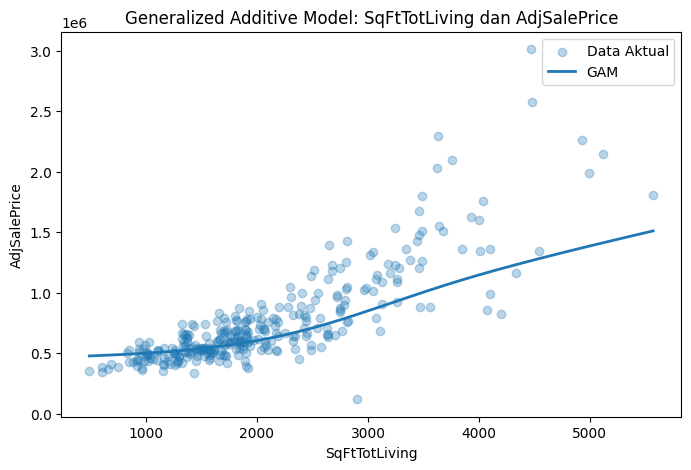

In [146]:
plt.figure(figsize=(8, 5))

plt.scatter(
    house_98105['SqFtTotLiving'],
    house_98105['AdjSalePrice'],
    alpha=0.3,
    label='Data Aktual'
)

plt.plot(
    sqft_gam,
    pred_curve_gam,
    linewidth=2,
    label='GAM'
)

plt.xlabel('SqFtTotLiving')
plt.ylabel('AdjSalePrice')
plt.title(
    'Generalized Additive Model: '
    'SqFtTotLiving dan AdjSalePrice'
)

plt.legend()

plt.show()

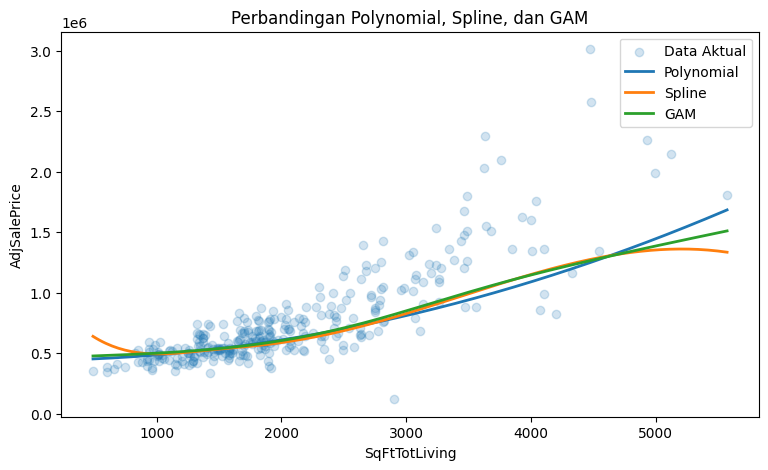

In [147]:
plt.figure(figsize=(9, 5))

plt.scatter(
    house_98105['SqFtTotLiving'],
    house_98105['AdjSalePrice'],
    alpha=0.20,
    label='Data Aktual'
)

plt.plot(
    sqft_grid,
    pred_poly,
    linewidth=2,
    label='Polynomial'
)

plt.plot(
    sqft_grid,
    pred_spline,
    linewidth=2,
    label='Spline'
)

plt.plot(
    sqft_gam,
    pred_curve_gam,
    linewidth=2,
    label='GAM'
)

plt.xlabel('SqFtTotLiving')
plt.ylabel('AdjSalePrice')

plt.title(
    'Perbandingan Polynomial, Spline, dan GAM'
)

plt.legend()

plt.show()

### Polynomial, Spline, dan GAM

Ketiga metode digunakan untuk menangkap hubungan nonlinear, tetapi pendekatannya berbeda.

**Polynomial Regression**

Menggunakan pangkat prediktor seperti \(X^2\) atau \(X^3\).

**Spline Regression**

Menggunakan beberapa segmen polynomial yang bertemu pada knots.

**Generalized Additive Model**

Menggunakan fungsi smooth sehingga hubungan nonlinear dapat dimodelkan dengan lebih fleksibel.

GAM dapat menjadi pilihan ketika bentuk hubungan nonlinear tidak diketahui dengan jelas sebelumnya.

### Interpretasi Hasil GAM

Pada contoh King County Housing Data, `SqFtTotLiving` tidak dipaksa mengikuti satu hubungan linear dengan harga rumah.

GAM memungkinkan efek luas rumah berubah secara fleksibel pada berbagai ukuran rumah.

Prediktor lain seperti SqFtLot, Bathrooms, Bedrooms, dan BldgGrade tetap dimodelkan menggunakan komponen linear.

Hal ini menunjukkan bahwa sebuah model tidak harus memperlakukan seluruh prediktor dengan bentuk hubungan yang sama.

### Ringkasan Generalized Additive Models

- GAM digunakan untuk memodelkan hubungan nonlinear secara fleksibel.
- GAM dapat menggabungkan smooth terms dan linear terms dalam satu model.
- Pada contoh ini, SqFtTotLiving menggunakan smooth term.
- Prediktor lainnya tetap menggunakan hubungan linear.
- `n_splines` mengontrol fleksibilitas smooth term.
- Jumlah spline yang terlalu besar dapat menyebabkan overfitting.
- Buku menggunakan 12 spline untuk menghasilkan fit yang lebih masuk akal.
- GAM dapat membantu mengurangi kebutuhan menentukan bentuk nonlinear secara manual.

# Chapter 4 Summary — Regression and Prediction

Chapter 4 membahas regresi sebagai salah satu metode statistik yang paling banyak digunakan untuk memahami hubungan antara variabel prediktor dan variabel respons serta untuk melakukan prediksi.

## 1. Simple Linear Regression

Simple linear regression menggunakan satu variabel prediktor untuk menjelaskan atau memprediksi variabel respons.

Model dasarnya:

$$
Y = b_0 + b_1X + e
$$

dengan:

- \(b_0\) = intercept,
- \(b_1\) = koefisien prediktor,
- \(e\) = residual.

Model diestimasi menggunakan metode least squares dengan meminimalkan jumlah kuadrat residual.

---

## 2. Multiple Linear Regression

Multiple linear regression menggunakan beberapa prediktor secara bersamaan:

$$
Y =
b_0 +
b_1X_1 +
b_2X_2 +
\cdots +
b_pX_p +
e
$$

Setiap koefisien menggambarkan hubungan antara satu prediktor dan respons ketika prediktor lain dianggap tetap.

Contoh utama pada chapter ini menggunakan King County Housing Data untuk memprediksi `AdjSalePrice`.

---

## 3. Evaluasi Model

Beberapa ukuran yang digunakan untuk mengevaluasi regresi adalah:

- RMSE,
- RSE,
- R-squared,
- Adjusted R-squared,
- AIC.

Evaluasi terhadap data training saja belum cukup untuk menilai kemampuan model dalam memprediksi data baru.

Karena itu, cross-validation digunakan untuk mengevaluasi performa out-of-sample dan kemampuan generalisasi model.

---

## 4. Model Selection

Tidak semua prediktor harus dimasukkan ke dalam model.

Model selection digunakan untuk memperoleh model yang lebih sederhana dan tetap memiliki kemampuan prediksi yang baik.

Pendekatan yang dibahas meliputi:

- forward selection,
- backward selection,
- stepwise regression,
- serta kriteria seperti AIC.

Model yang lebih kompleks tidak otomatis lebih baik karena dapat meningkatkan risiko overfitting.

---

## 5. Weighted Regression

Weighted regression memberikan bobot yang berbeda pada setiap observasi.

Observasi yang dianggap lebih relevan atau lebih dapat dipercaya dapat diberikan bobot lebih besar.

Pada King County Housing Data, transaksi yang lebih baru diberikan bobot lebih besar dibandingkan transaksi yang lebih lama.

---

## 6. Prediction Using Regression

Regresi dapat digunakan untuk memprediksi nilai respons pada observasi baru.

Namun, prediksi perlu memperhatikan beberapa hal:

- extrapolation,
- confidence interval,
- prediction interval.

Extrapolation dapat menghasilkan prediksi yang tidak masuk akal jika data baru berada jauh di luar rentang data training.

Prediction interval biasanya lebih lebar daripada confidence interval karena mencakup ketidakpastian model sekaligus variasi individual observasi.

---

## 7. Factor Variables

Variabel kategorikal perlu dikonversi ke bentuk numerik sebelum digunakan dalam regresi.

Metode yang umum digunakan adalah dummy variables.

Jika sebuah factor memiliki \(P\) kategori, biasanya digunakan:

$$
P-1
$$

dummy variables sehingga satu kategori menjadi reference category.

Factor dengan terlalu banyak level juga dapat digabungkan menjadi kelompok yang lebih sedikit.

---

## 8. Interpretasi Persamaan Regresi

Interpretasi koefisien regresi harus dilakukan dengan hati-hati.

Beberapa masalah penting meliputi:

### Correlated Predictors

Prediktor yang saling berkorelasi dapat menyebabkan tanda dan besar koefisien sulit diinterpretasikan.

### Multicollinearity

Multicollinearity terjadi ketika terdapat redundansi yang sangat kuat di antara prediktor dan dapat menyebabkan estimasi koefisien menjadi tidak stabil.

### Confounding Variables

Confounding terjadi ketika prediktor penting tidak dimasukkan ke dalam model sehingga hubungan antarvariabel dapat terlihat menyesatkan.

### Interactions

Interaction digunakan ketika pengaruh satu prediktor terhadap respons bergantung pada prediktor lainnya.

---

## 9. Regression Diagnostics

Residual dapat digunakan untuk mengevaluasi kelemahan model regresi.

Beberapa diagnostik yang dibahas meliputi:

- outliers,
- standardized residuals,
- influential values,
- leverage,
- Cook's Distance,
- heteroskedasticity,
- non-normal residuals,
- correlated errors,
- partial residual plots.

Outlier merupakan observasi dengan residual besar, sedangkan influential observation merupakan observasi yang keberadaan atau penghapusannya dapat mengubah persamaan regresi secara signifikan.

Partial residual plot dapat digunakan untuk melihat apakah hubungan antara suatu prediktor dan respons benar-benar linear.

---

## 10. Nonlinear Relationships

Hubungan antara prediktor dan respons tidak selalu linear.

Chapter ini membahas tiga pendekatan untuk menangani nonlinearity.

### Polynomial Regression

Polynomial regression menambahkan bentuk pangkat dari prediktor seperti:

$$
X^2,\ X^3,\ \text{dan seterusnya}
$$

### Spline Regression

Spline menggunakan beberapa segmen polynomial yang disambungkan pada titik yang disebut knots.

### Generalized Additive Models

GAM memberikan pendekatan yang lebih fleksibel untuk membentuk smooth nonlinear relationships dan dapat mengotomatisasi penggunaan spline.

---

## Kesimpulan

Regression merupakan metode penting untuk explanatory modeling maupun predictive modeling.

Dalam pendekatan statistik klasik, perhatian sering diberikan pada seberapa baik model menjelaskan data yang telah diamati.

Dalam data science, perhatian lebih besar diberikan pada kemampuan model untuk memprediksi data baru.

Oleh karena itu, model sebaiknya tidak hanya dievaluasi menggunakan ukuran in-sample, tetapi juga menggunakan evaluasi out-of-sample seperti cross-validation.

Pemilihan variabel, pemeriksaan residual, interaction, serta penggunaan polynomial, spline, dan GAM memungkinkan model regresi dikembangkan menjadi lebih fleksibel sesuai struktur data.

## Key Takeaways

- Regression digunakan untuk menjelaskan hubungan dan melakukan prediksi.
- Multiple regression memungkinkan beberapa prediktor digunakan secara bersamaan.
- Cross-validation penting untuk menilai kemampuan generalisasi model.
- Correlation, multicollinearity, dan confounding dapat memengaruhi interpretasi koefisien.
- Interaction digunakan ketika efek suatu prediktor bergantung pada prediktor lain.
- Residual diagnostics membantu menemukan kelemahan model.
- Polynomial regression, spline, dan GAM memungkinkan pemodelan hubungan nonlinear.
- Dalam data science, performa out-of-sample lebih penting daripada hanya kecocokan terhadap data training.